# Kampala Air Quality and Respiratory Health Analysis - Monthly Pipeline

All charts, calculations, and tables use calendar-month observations. Monthly environmental and DHIS2 data from `analysis.ipynb` are aggregated to months, and the overall pneumonia/cough-and-cold monthly dataset replaces severe pneumonia under five.


# Step 1: Load, Combine, and Aggregate Data by Month


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import geopandas as gpd
from datetime import date
from pathlib import Path
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [2]:
# Load the monthly inputs used in analysis.ipynb
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

# Join the monthly climate and PM2.5 sources, then assign each ISO week to its Sunday.
monthly_df = pd.merge(
    clim_df, plo_df, left_on=['epi_year', 'epi_week'], right_on=['year', 'week'], how='inner'
).drop(columns=['year', 'week'])
monthly_df['date'] = monthly_df.apply(
    lambda row: pd.Timestamp(date.fromisocalendar(int(row['epi_year']), int(row['epi_week']), 7)), axis=1
)

# Extract the monthly DHIS2 reporting date and retain all original non-pneumonia indicators.
resp_df['date'] = pd.to_datetime(resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')[0], errors='coerce')
resp_df = resp_df.drop(columns=['periodname'])
monthly_df = pd.merge(monthly_df, resp_df, on='date', how='inner')

# Overall pneumonia and cough/cold data are supplied at monthly frequency.
overall_df = pd.read_csv('data/Overall Pneumonia data_cough and cold.csv')
overall_df['month_start'] = pd.to_datetime(overall_df['periodname'], format='%b-%y', errors='coerce')
overall_df = overall_df.rename(columns={
    '105-CD12. Pneumonia': 'pneumonia',
    '105-CD13. Severe Pneumonia': 'severe_pneumonia',
    '108-CD06b. Pneumonia  - Deaths': 'pneumonia_deaths',
    '105-CD11. Cough or cold  - No Pneumonia': 'cough_cold'
})
overall_df = overall_df[['month_start', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']]


In [3]:
# Aggregate the monthly sources to calendar months.
monthly_df = monthly_df.rename(columns={
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'ILD deaths': 'ILD_deaths',
    'SARI Cases': 'SARI',
    'SARI Deaths': 'SARI_deaths'
})
monthly_df['month_start'] = monthly_df['date'].dt.to_period('M').dt.to_timestamp()

environment_cols = ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip']
monthly_count_cols = [c for c in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths'] if c in monthly_df.columns]
monthly_aggregation = {**{c: 'mean' for c in environment_cols if c in monthly_df.columns}, **{c: 'sum' for c in monthly_count_cols}}
merged_df = monthly_df.groupby('month_start', as_index=False).agg(monthly_aggregation)
merged_df = merged_df.merge(overall_df, on='month_start', how='outer').sort_values('month_start').reset_index(drop=True)
merged_df = merged_df.rename(columns={'month_start': 'date'})

print(f"Monthly dataset: {len(merged_df)} observations from {merged_df['date'].min():%b %Y} to {merged_df['date'].max():%b %Y}")


Monthly dataset: 60 observations from Jan 2020 to Dec 2024


In [4]:
# Impute environmental measurements only; missing case counts mean no reported cases.
cols_to_impute = [c for c in ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip'] if c in merged_df.columns]
merged_df[cols_to_impute] = merged_df[cols_to_impute].interpolate(limit_direction='both').ffill().bfill()
monthly_disease_cols = ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
merged_df[monthly_disease_cols] = merged_df[monthly_disease_cols].fillna(0)
merged_df['year'] = merged_df['date'].dt.year
merged_df['month'] = merged_df['date'].dt.month
merged_df.to_csv('data/merged_climate_respiratory_monthly.csv', index=False)
print('Saved monthly merged data to data/merged_climate_respiratory_monthly.csv')


Saved monthly merged data to data/merged_climate_respiratory_monthly.csv


In [5]:
# Initialize the existing processor with the monthly dataset.
processor = SimplifiedDataProcessor(data_dir='../data')
data = processor.load_data('./data/merged_climate_respiratory_monthly.csv')
print(f"? Loaded {len(data)} monthly records")


INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_respiratory_monthly.csv
INFO:simplified_data_processor:Loaded 60 records
INFO:simplified_data_processor:Data processing complete: 60 records


? Loaded 60 monthly records


In [6]:
# Add lag features and rolling averages
processed_data = processor.add_lag_features()

# Add extra engineered features so they pass through the same initial pipeline
processed_data['date'] = pd.to_datetime(processed_data['date'], errors='coerce', dayfirst=True)
processed_data['temp_humidity_interaction'] = processed_data['avgtemp'] * processed_data['avghumidity']
processed_data['temp_sat_gap'] = processed_data['avgtemp'] - processed_data.get('avgtemp_sat', processed_data['avgtemp'])
processed_data['humidity_sat_gap'] = processed_data['avghumidity'] - processed_data.get('humidity_sat', processed_data['avghumidity'])
processed_data['precip_rolling_4'] = processed_data['precip'].rolling(window=4, min_periods=1).mean()
processed_data['windspeed_rolling_4'] = processed_data['windspeed'].rolling(window=4, min_periods=1).mean()

for window in [7, 14, 30]:
    processed_data[f'pm25_trailing_ma_{window}'] = processed_data['pm2_5'].rolling(window=window, min_periods=1).mean()
    processed_data[f'tb_trailing_ma_{window}'] = processed_data['TB'].rolling(window=window, min_periods=1).mean()
    processed_data[f'pm25_leading_ma_{window}'] = (
        processed_data['pm2_5'].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
    )
    processed_data[f'tb_leading_ma_{window}'] = (
        processed_data['TB'].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
    )

processed_data['pm25_temp_ratio'] = processed_data['pm2_5'] / (processed_data['avgtemp'].abs() + 1)
processed_data['pm25_humidity_ratio'] = processed_data['pm2_5'] / (processed_data['avghumidity'].abs() + 1)
processed_data['tb_pct_change_1'] = processed_data['TB'].pct_change().replace([np.inf, -np.inf], np.nan)
processed_data['tb_diff_1'] = processed_data['TB'].diff()
processed_data['sin_week'] = np.sin(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['cos_week'] = np.cos(2 * np.pi * processed_data['week_of_year'] / 52)
processed_data['sin_month'] = np.sin(2 * np.pi * processed_data['month'] / 12)
processed_data['cos_month'] = np.cos(2 * np.pi * processed_data['month'] / 12)

print(f"✓ Added features: {processed_data.shape[1]} total columns")


INFO:simplified_data_processor:Added lag features and rolling averages


✓ Added features: 78 total columns


In [7]:
# Get summary statistics
summary = processor.get_summary_statistics()
print("\nData Summary:")
print(f"- Date range: {summary['date_range']}")
print(f"- Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"- Total TB cases: {summary['tb_statistics']['total_cases']}")
print(f"- PM2.5-TB correlation: {summary['correlation_pm25_tb']:.3f}")



Data Summary:
- Date range: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
- Average PM2.5: 39.36 μg/m³
- Total TB cases: 156373.0
- PM2.5-TB correlation: -0.048


In [8]:
# Display first few rows including diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]
preview_cols = [
    'date', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + disease_cols + [
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]
preview_cols = [col for col in preview_cols if col in processed_data.columns]
processed_data[preview_cols].head(10)


,date,pm2_5,avgtemp,avghumidity,windspeed,precip,TB,ILI,ILD_deaths,SARI,...,precip_rolling_4,windspeed_rolling_4,pm25_temp_ratio,pm25_humidity_ratio,tb_pct_change_1,tb_diff_1,sin_week,cos_week,sin_month,cos_month
0,2020-01-01,69.0750,24.0150,68.3725,2.4900,8.8750,114.0,0.0,0.0,135,...,8.875000,2.490000,2.761343,0.995712,NaN,NaN,0.120537,0.992709,5.000000e-01,8.660254e-01
1,2020-02-01,45.2225,23.3525,77.5575,2.1025,42.6225,1083.0,135.0,0.0,598,...,25.748750,2.296250,1.856996,0.575661,8.500000,969.0,0.568065,0.822984,8.660254e-01,5.000000e-01
2,2020-03-01,35.9580,23.2420,83.0680,2.1080,59.2760,1650.0,202.0,3.0,1155,...,36.924500,2.233500,1.483293,0.427725,0.523546,567.0,0.885456,0.464723,1.000000e+00,6.123234e-17
3,2020-04-01,24.3975,23.3250,83.0475,2.1575,30.9750,979.0,70.0,0.0,411,...,35.437125,2.214500,1.002980,0.290282,-0.406667,-671.0,0.992709,-0.120537,8.660254e-01,-5.000000e-01
4,2020-05-01,27.3100,22.7460,84.6700,2.9300,42.7240,1540.0,3592.0,0.0,877,...,43.899375,2.324500,1.150088,0.318781,0.573034,561.0,0.822984,-0.568065,5.000000e-01,-8.660254e-01
5,2020-06-01,39.7900,22.4300,80.0025,3.5450,16.1925,1406.0,109.0,0.0,546,...,37.291875,2.685125,1.698250,0.491219,-0.087013,-134.0,0.354605,-0.935016,1.224647e-16,-1.000000e+00
6,2020-07-01,51.9050,21.9425,78.6200,3.8150,8.0525,1620.0,61.0,0.0,421,...,24.486000,3.111875,2.262395,0.651909,0.152205,214.0,-0.120537,-0.992709,-5.000000e-01,-8.660254e-01
7,2020-08-01,48.2540,22.2180,80.1840,2.6820,15.9180,1955.0,312.0,0.0,671,...,20.721750,3.243000,2.078301,0.594378,0.206790,335.0,-0.568065,-0.822984,-8.660254e-01,-5.000000e-01
8,2020-09-01,41.0925,22.0175,82.1775,2.0550,26.4875,1626.0,51.0,0.0,594,...,16.662625,3.024250,1.785272,0.494034,-0.168286,-329.0,-0.935016,-0.354605,-1.000000e+00,-1.836970e-16
9,2020-10-01,33.1075,22.0775,82.4175,1.8325,28.2450,1624.0,55.0,0.0,684,...,19.675750,2.596125,1.434622,0.396889,-0.001230,-2.0,-0.992709,0.120537,-8.660254e-01,5.000000e-01


In [9]:
# Monthly tables: annual totals and calendar-month averages.
monthly_disease_cols = [c for c in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold'] if c in processed_data.columns]
annual_monthly_totals = processed_data.groupby(processed_data['date'].dt.year)[monthly_disease_cols].sum().round(0).astype(int)
calendar_month_means = processed_data.groupby(processed_data['date'].dt.month)[['pm2_5'] + monthly_disease_cols].mean().round(2).reindex(range(1, 13))
print('Annual totals calculated from monthly observations')
display(annual_monthly_totals)
print('Average value by calendar month across all years')
display(calendar_month_means)


Annual totals calculated from monthly observations


,TB,ILI,ILD_deaths,SARI,SARI_deaths,pneumonia,severe_pneumonia,pneumonia_deaths,cough_cold
date,,,,,,,,,
2020,17171,4911,6798,7407,36,16865,3742,361,230480
2021,23511,1239,148,10438,213,25933,7339,407,273419
2022,36286,2567,92,13673,57,30651,4619,545,356403
2023,38311,4842,232,8592,68,22735,3639,495,319189
2024,41094,69389,129,14481,77,24387,4937,582,306990


Average value by calendar month across all years


,pm2_5,TB,ILI,ILD_deaths,SARI,SARI_deaths,pneumonia,severe_pneumonia,pneumonia_deaths,cough_cold
date,,,,,,,,,,
1,55.68,1976.4,382.8,6.6,1228.6,6.2,1727.8,435.2,42.2,24174.8
2,49.30,2586.6,525.2,1.4,659.4,8.0,2015.4,361.0,34.2,24640.6
3,33.48,2908.8,861.4,6.8,904.8,6.2,2288.8,446.0,28.0,28427.8
4,23.28,2344.2,669.2,4.2,650.0,4.4,2086.8,381.4,37.8,25097.8
5,28.07,2552.6,1358.0,18.4,750.0,2.4,2227.4,507.0,47.0,25346.6
6,39.37,2336.6,990.8,31.0,1123.2,12.2,2391.8,550.8,55.2,27579.0
7,47.84,2928.6,1729.4,9.8,1112.6,11.4,1902.4,415.2,42.6,23997.0
8,45.11,2885.8,2708.0,19.8,1067.6,5.8,1831.2,312.8,41.0,24523.0
9,38.41,2937.0,2269.8,6.0,823.8,14.4,1678.2,315.4,35.2,20973.4


## Step 2: Exploratory Data Analysis


### 2.1 Time Series Overview


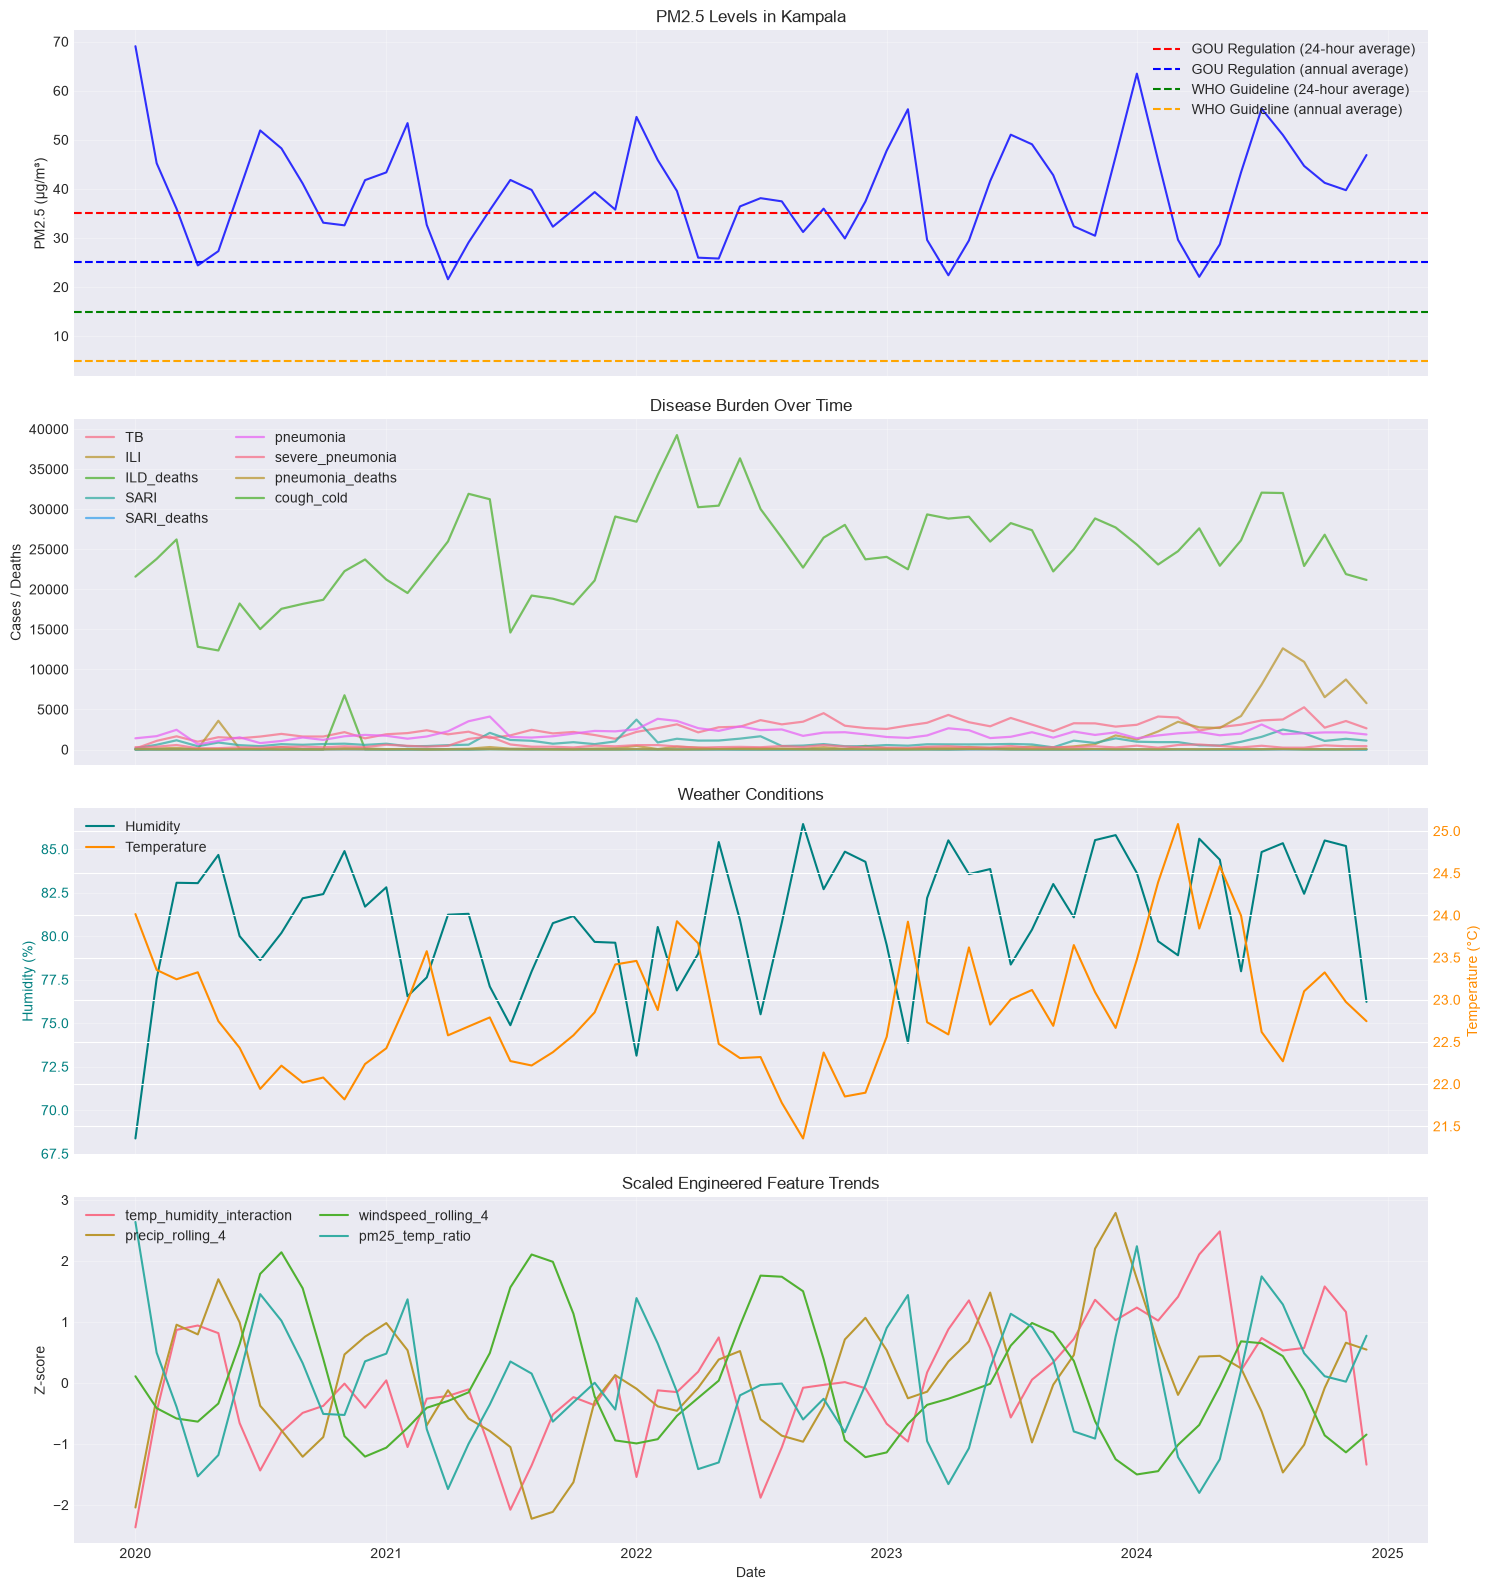

In [10]:
# Time series overview for air quality, diseases, and weather
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes[0].plot(processed_data['date'], processed_data['pm2_5'], color='blue', alpha=0.8)
axes[0].axhline(y=35, color='red', linestyle='--', label='GOU Regulation (24-hour average)')
axes[0].axhline(y=25, color='blue', linestyle='--', label='GOU Regulation (annual average)')
axes[0].axhline(y=15, color='green', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (annual average)')
axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for disease in disease_cols:
    axes[1].plot(processed_data['date'], processed_data[disease], alpha=0.75, linewidth=1.6, label=disease)
axes[1].set_title('Disease Burden Over Time')
axes[1].set_ylabel('Cases / Deaths')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(True, alpha=0.3)

weather_ax = axes[2]
temperature_ax = weather_ax.twinx()
weather_ax.plot(processed_data['date'], processed_data['avghumidity'], color='teal', label='Humidity')
temperature_ax.plot(processed_data['date'], processed_data['avgtemp'], color='darkorange', label='Temperature')
weather_ax.set_title('Weather Conditions')
weather_ax.set_ylabel('Humidity (%)', color='teal')
temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
weather_ax.tick_params(axis='y', labelcolor='teal')
temperature_ax.tick_params(axis='y', labelcolor='darkorange')
weather_ax.grid(True, alpha=0.3)
weather_handles, weather_labels = weather_ax.get_legend_handles_labels()
temp_handles, temp_labels = temperature_ax.get_legend_handles_labels()
weather_ax.legend(weather_handles + temp_handles, weather_labels + temp_labels, loc='upper left')

engineered_plot_cols = [
    col for col in ['temp_humidity_interaction', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio']
    if col in processed_data.columns
]
engineered_scaled = processed_data[engineered_plot_cols].copy()
for col in engineered_plot_cols:
    col_std = engineered_scaled[col].std()
    if pd.notna(col_std) and col_std != 0:
        engineered_scaled[col] = (engineered_scaled[col] - engineered_scaled[col].mean()) / col_std
    else:
        engineered_scaled[col] = 0
for col in engineered_plot_cols:
    axes[3].plot(processed_data['date'], engineered_scaled[col], linewidth=1.5, label=col)
axes[3].set_title('Scaled Engineered Feature Trends')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', ncol=2)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.2 Correlation Analysis


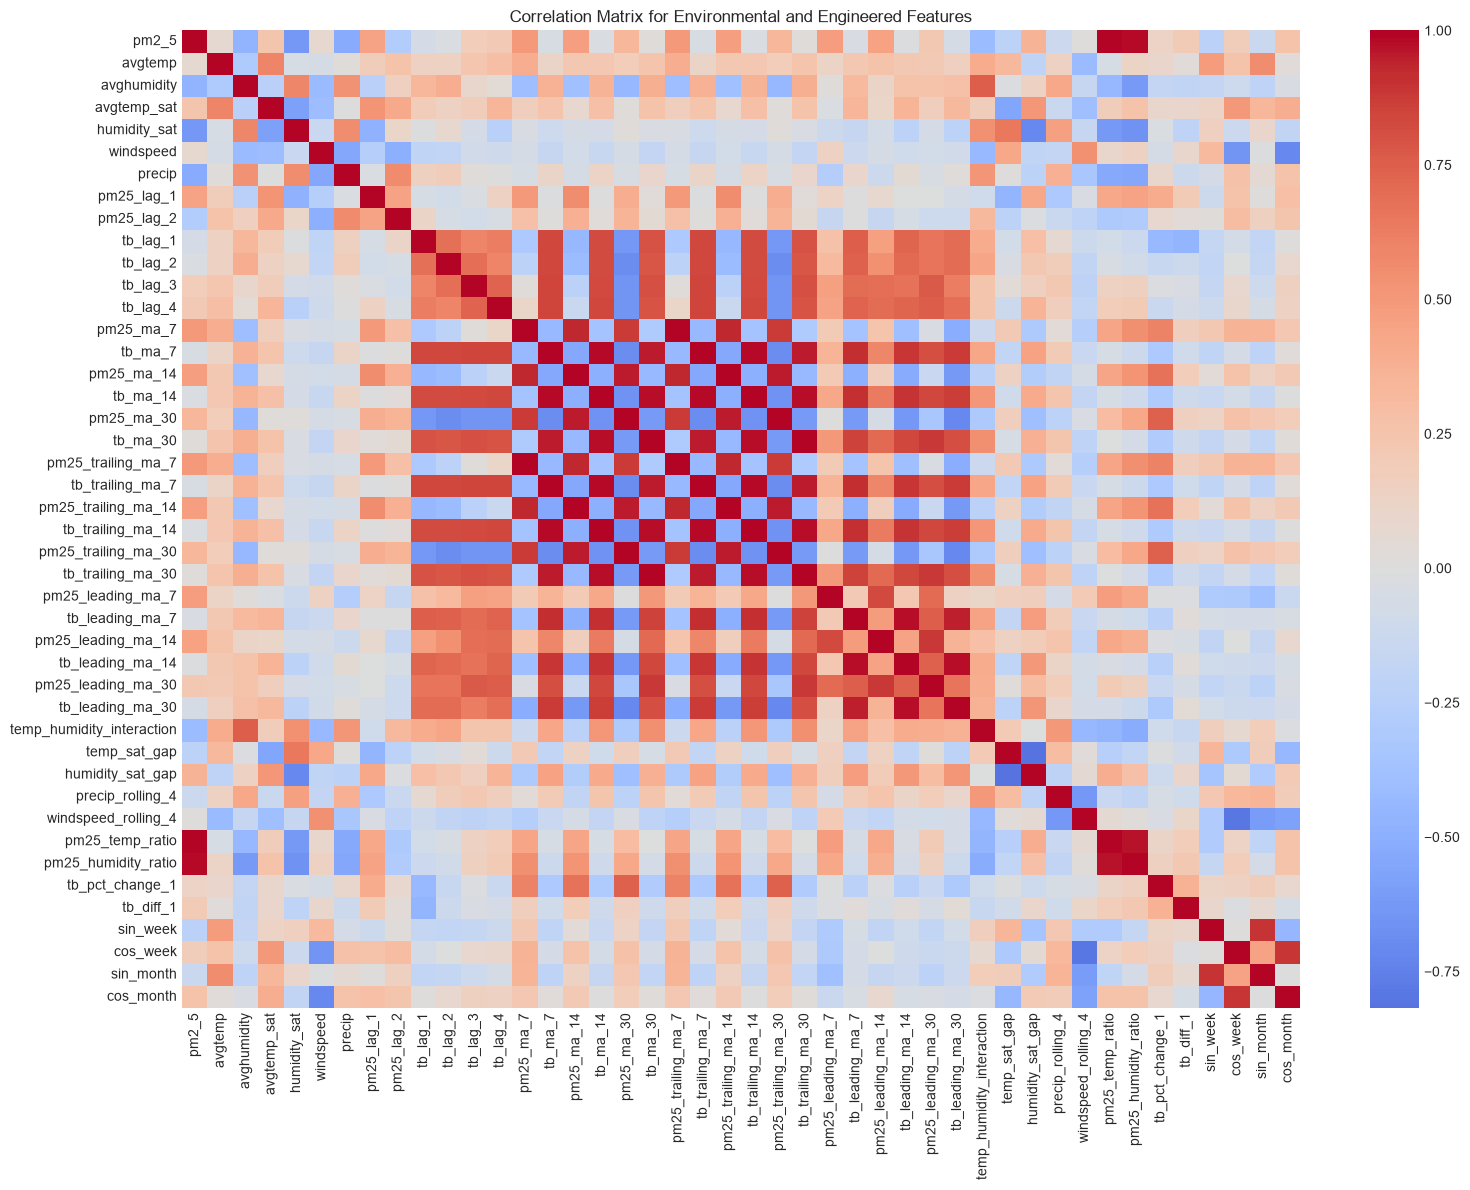

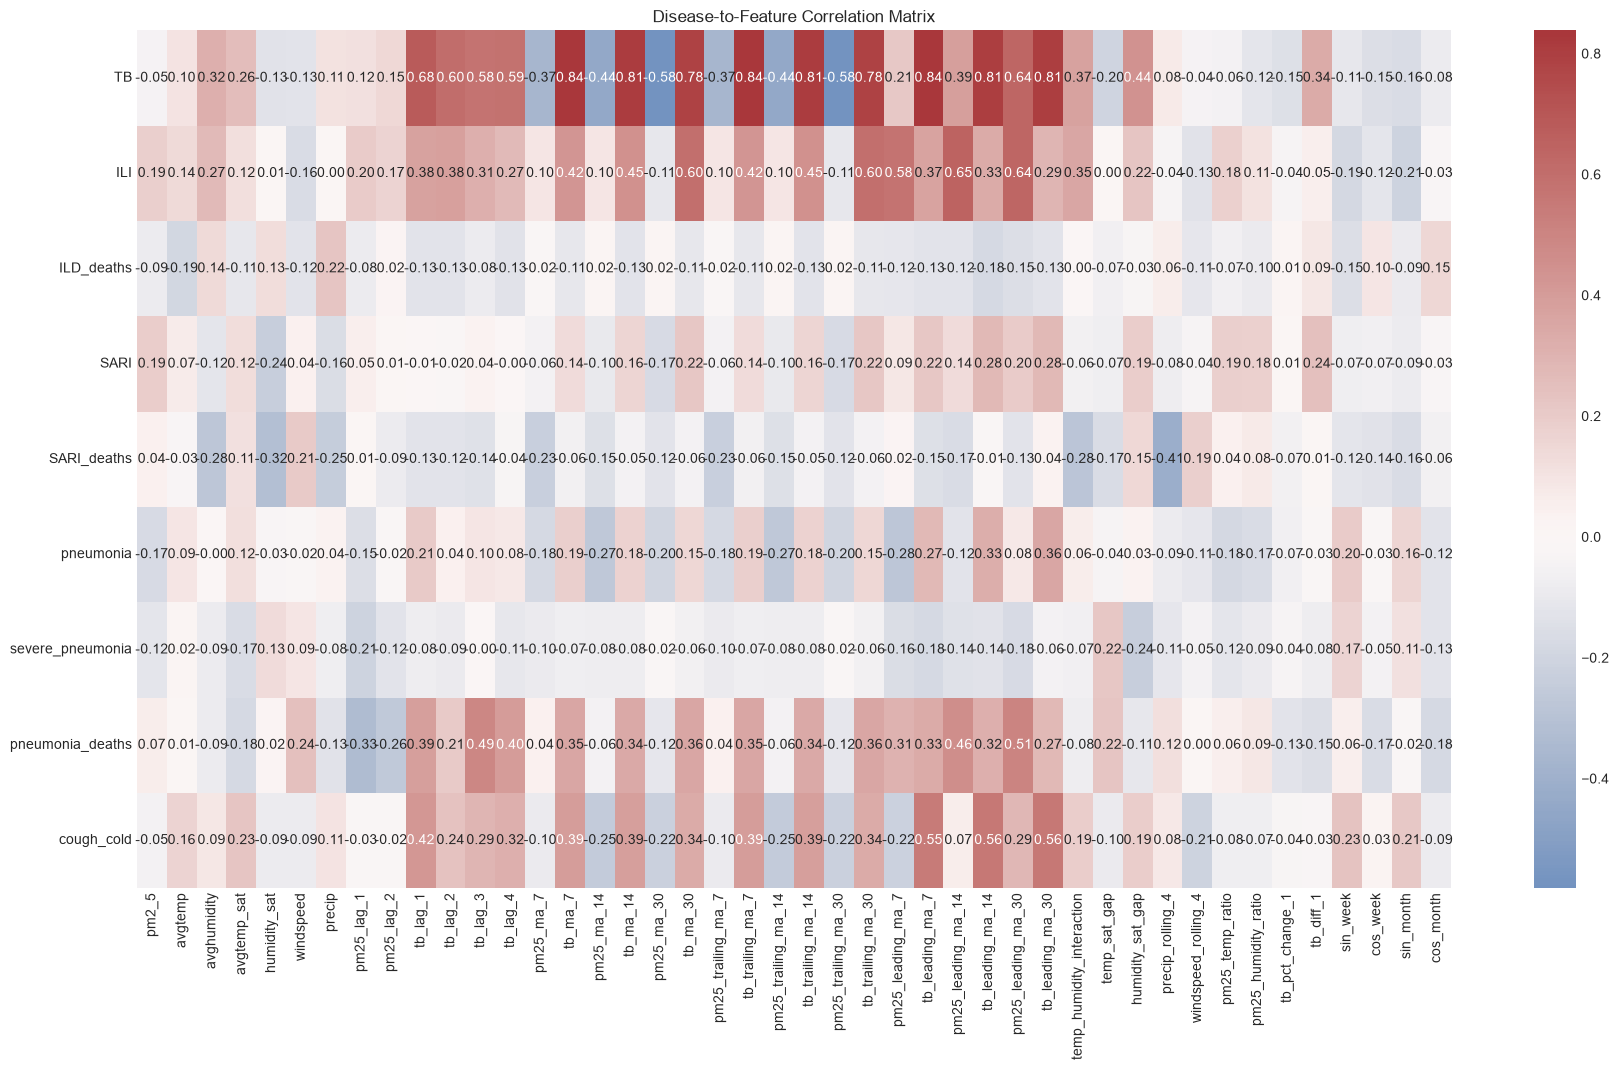

In [11]:
# Correlation analysis across diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
        'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
        'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
        'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

feature_corr_matrix = processed_data[feature_analysis_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Environmental and Engineered Features')
plt.tight_layout()
plt.show()

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
plt.figure(figsize=(18, max(4, len(disease_cols) * 1.2)))
sns.heatmap(disease_feature_corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Disease-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.3 Disease-Level Feature Ranking


In [12]:
# Disease-level feature ranking and pairwise relationships
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
        'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
        'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
        'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
        'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
        'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
        'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
        'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
        'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = (
    disease_feature_corr.abs()
    .stack()
    .reset_index(name='abs_correlation')
    .rename(columns={'level_0': 'disease', 'level_1': 'feature'})
    .sort_values(['disease', 'abs_correlation'], ascending=[True, False])
    .groupby('disease')
    .head(5)
)
strongest_links['correlation'] = strongest_links.apply(
    lambda row: disease_feature_corr.loc[row['disease'], row['feature']],
    axis=1
)
print('Top 5 absolute correlations per disease')
print(strongest_links[['disease', 'feature', 'correlation', 'abs_correlation']].to_string(index=False))

summary_stats = processed_data[disease_cols + feature_analysis_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
summary_stats.head(20)


Top 5 absolute correlations per disease
         disease                   feature  correlation  abs_correlation
      ILD_deaths                    precip     0.223823         0.223823
      ILD_deaths                   avgtemp    -0.189581         0.189581
      ILD_deaths          tb_leading_ma_14    -0.178694         0.178694
      ILD_deaths                 cos_month     0.153642         0.153642
      ILD_deaths        pm25_leading_ma_30    -0.153261         0.153261
             ILI        pm25_leading_ma_14     0.647864         0.647864
             ILI        pm25_leading_ma_30     0.636806         0.636806
             ILI                  tb_ma_30     0.595958         0.595958
             ILI         tb_trailing_ma_30     0.595958         0.595958
             ILI         pm25_leading_ma_7     0.575014         0.575014
            SARI          tb_leading_ma_14     0.277163         0.277163
            SARI          tb_leading_ma_30     0.276003         0.276003
           

,mean,std,min,max
TB,2606.216667,970.140792,114.0,5275.0
ILI,1382.466667,2769.983696,0.0,12633.0
ILD_deaths,123.316667,873.511218,0.0,6775.0
SARI,909.85,585.579991,135.0,3738.0
SARI_deaths,7.516667,10.06166,0.0,47.0
pneumonia,2009.516667,677.907086,650.0,4119.0
severe_pneumonia,404.6,235.021903,159.0,1620.0
pneumonia_deaths,39.833333,15.282833,8.0,95.0
cough_cold,24774.683333,5517.502083,12368.0,39249.0
pm2_5,39.360797,10.211729,21.58,69.075


### 2.4 PM2.5 vs Disease Scatter Plots


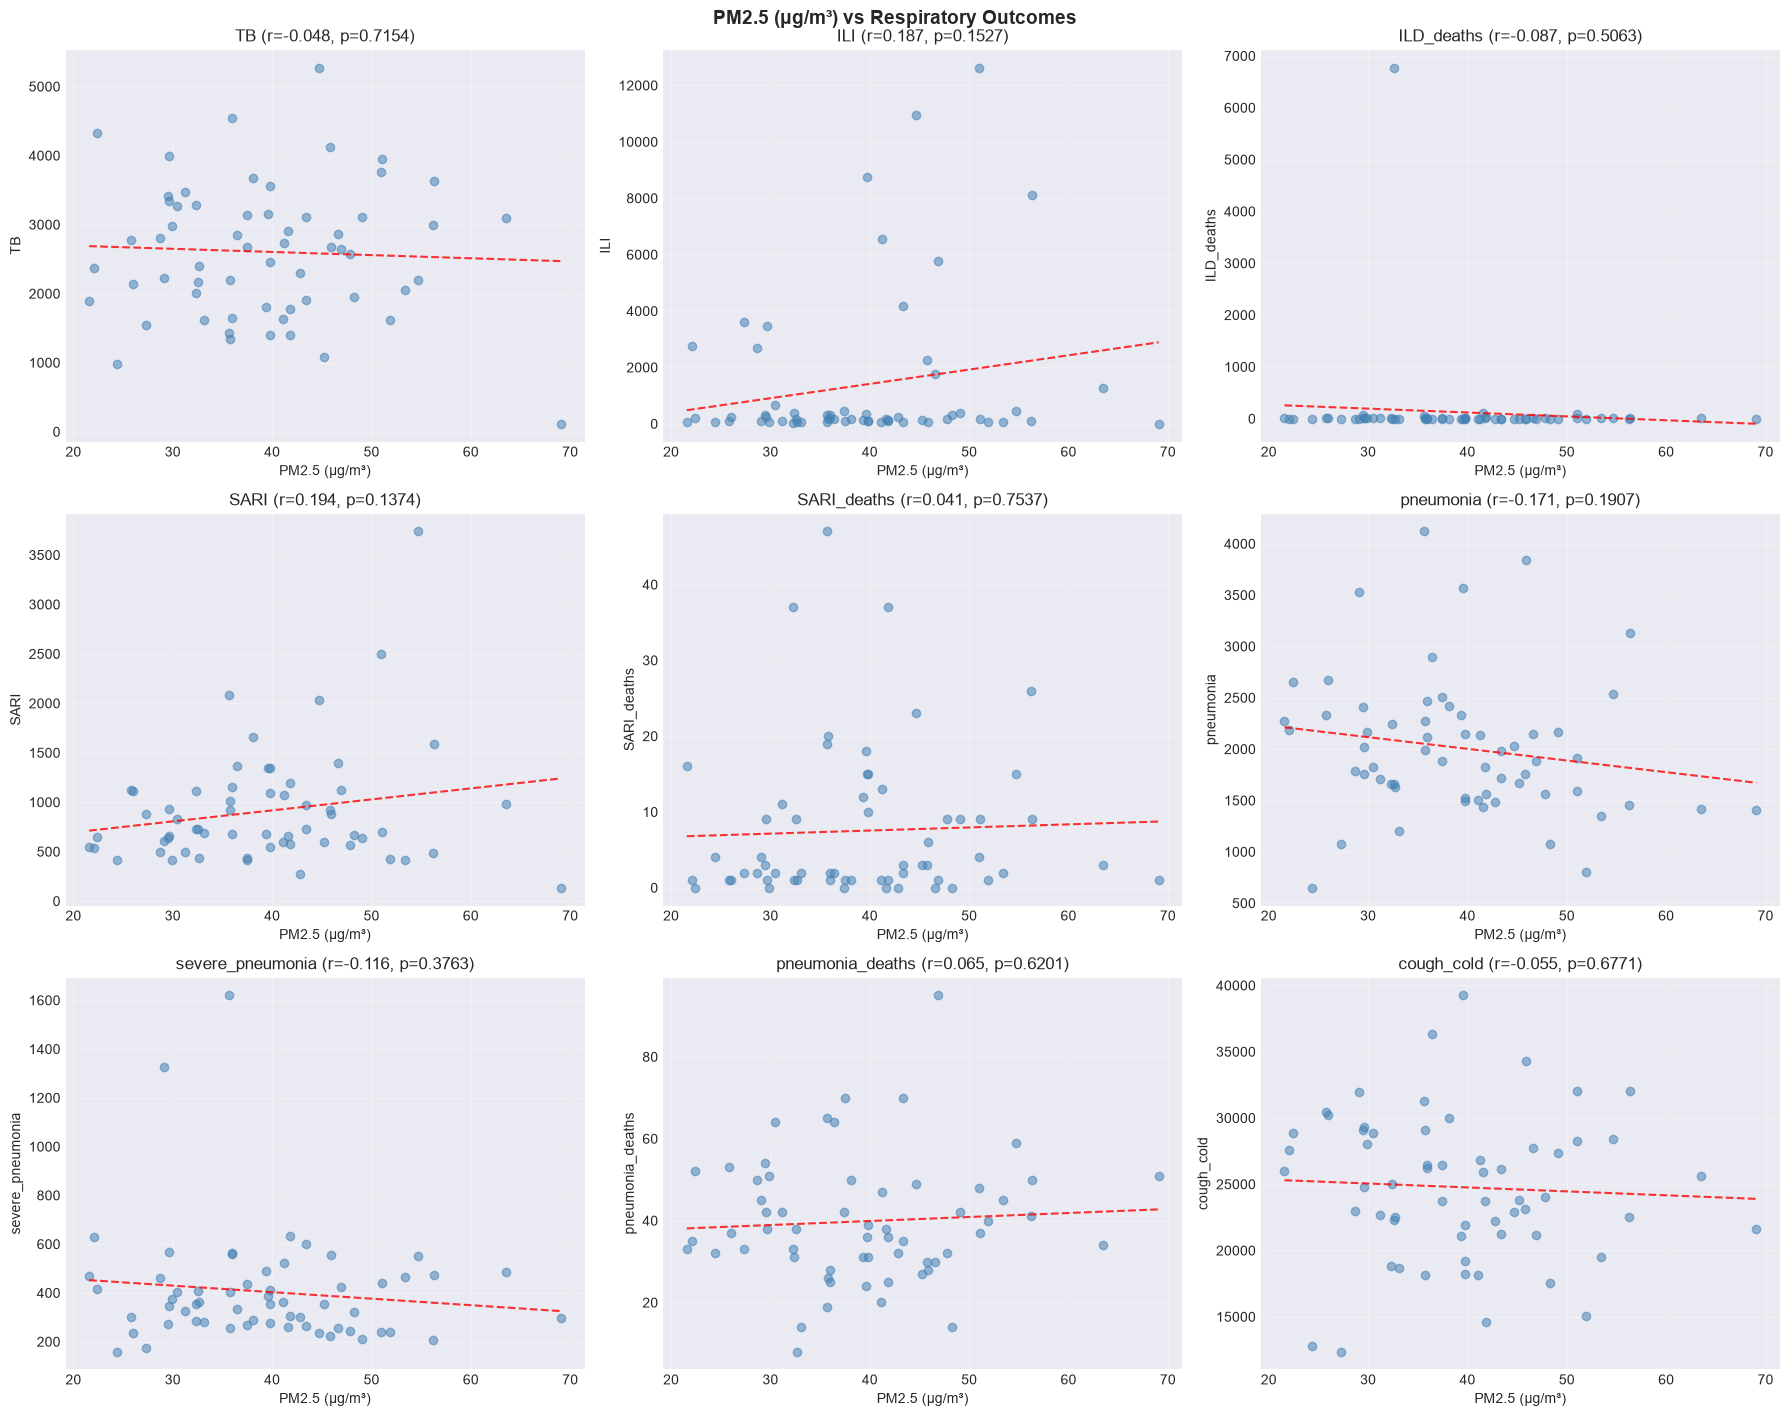

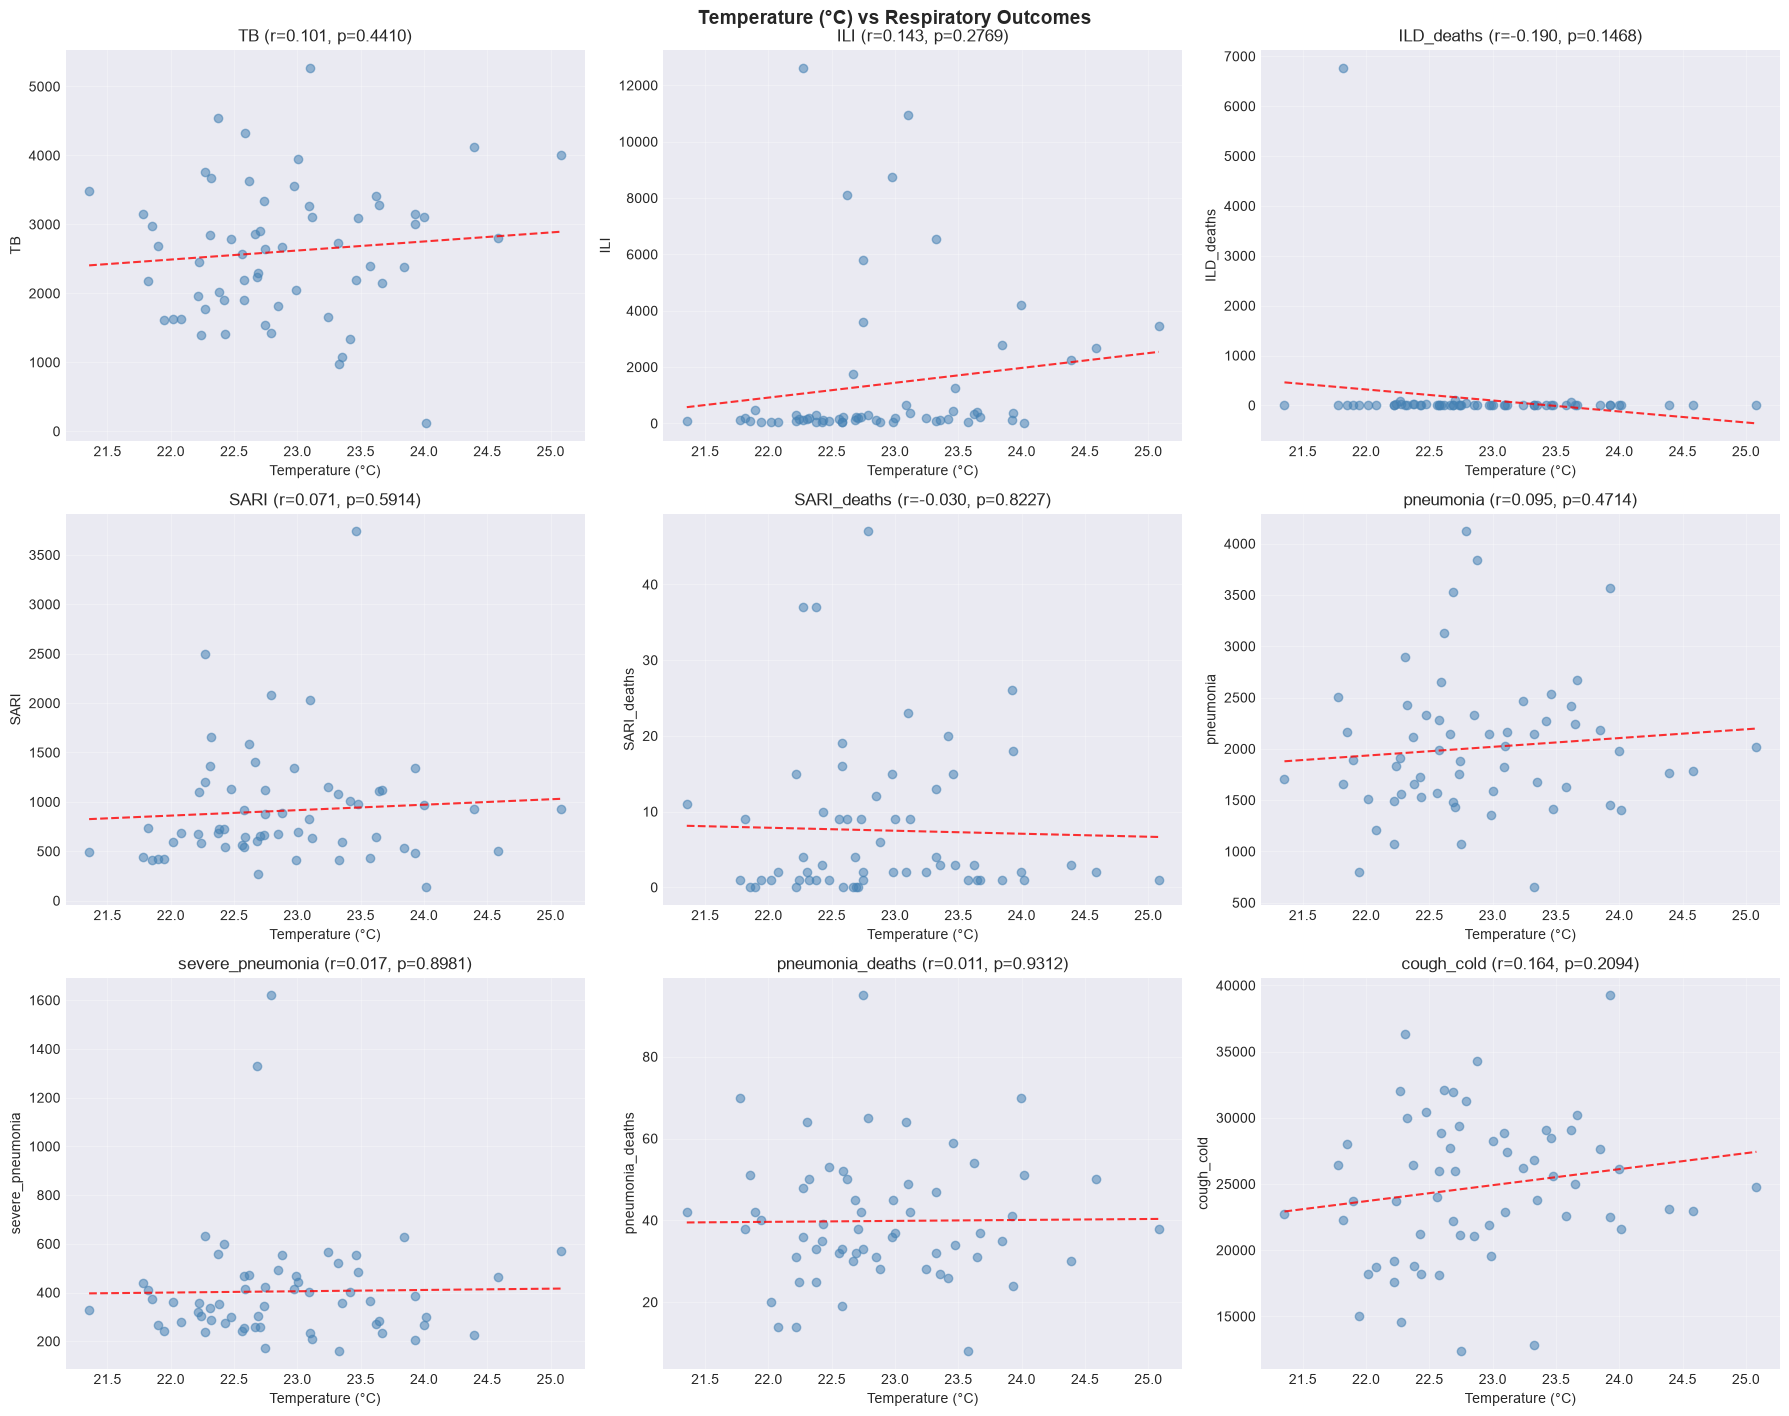

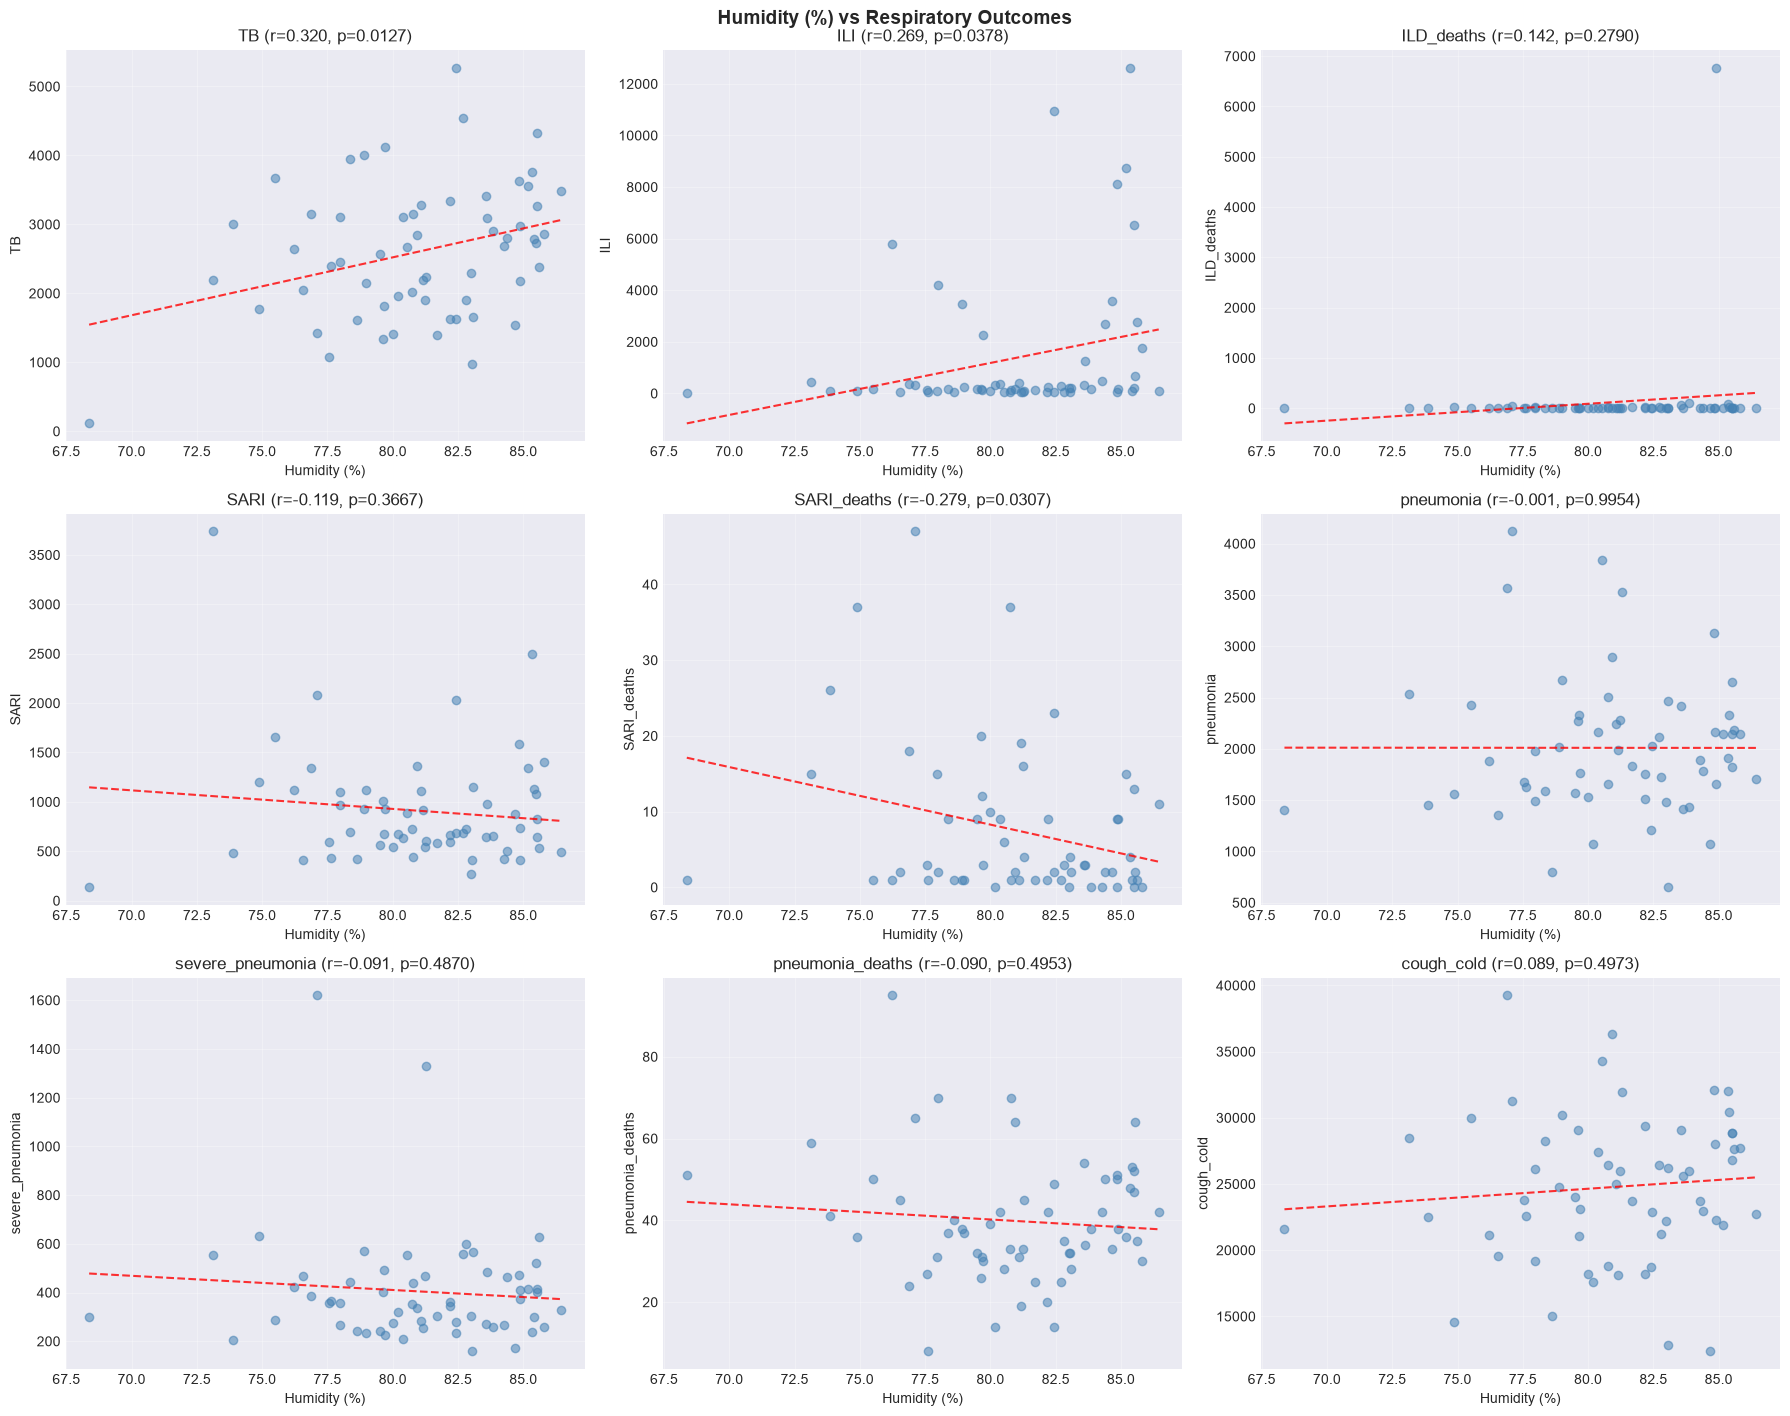

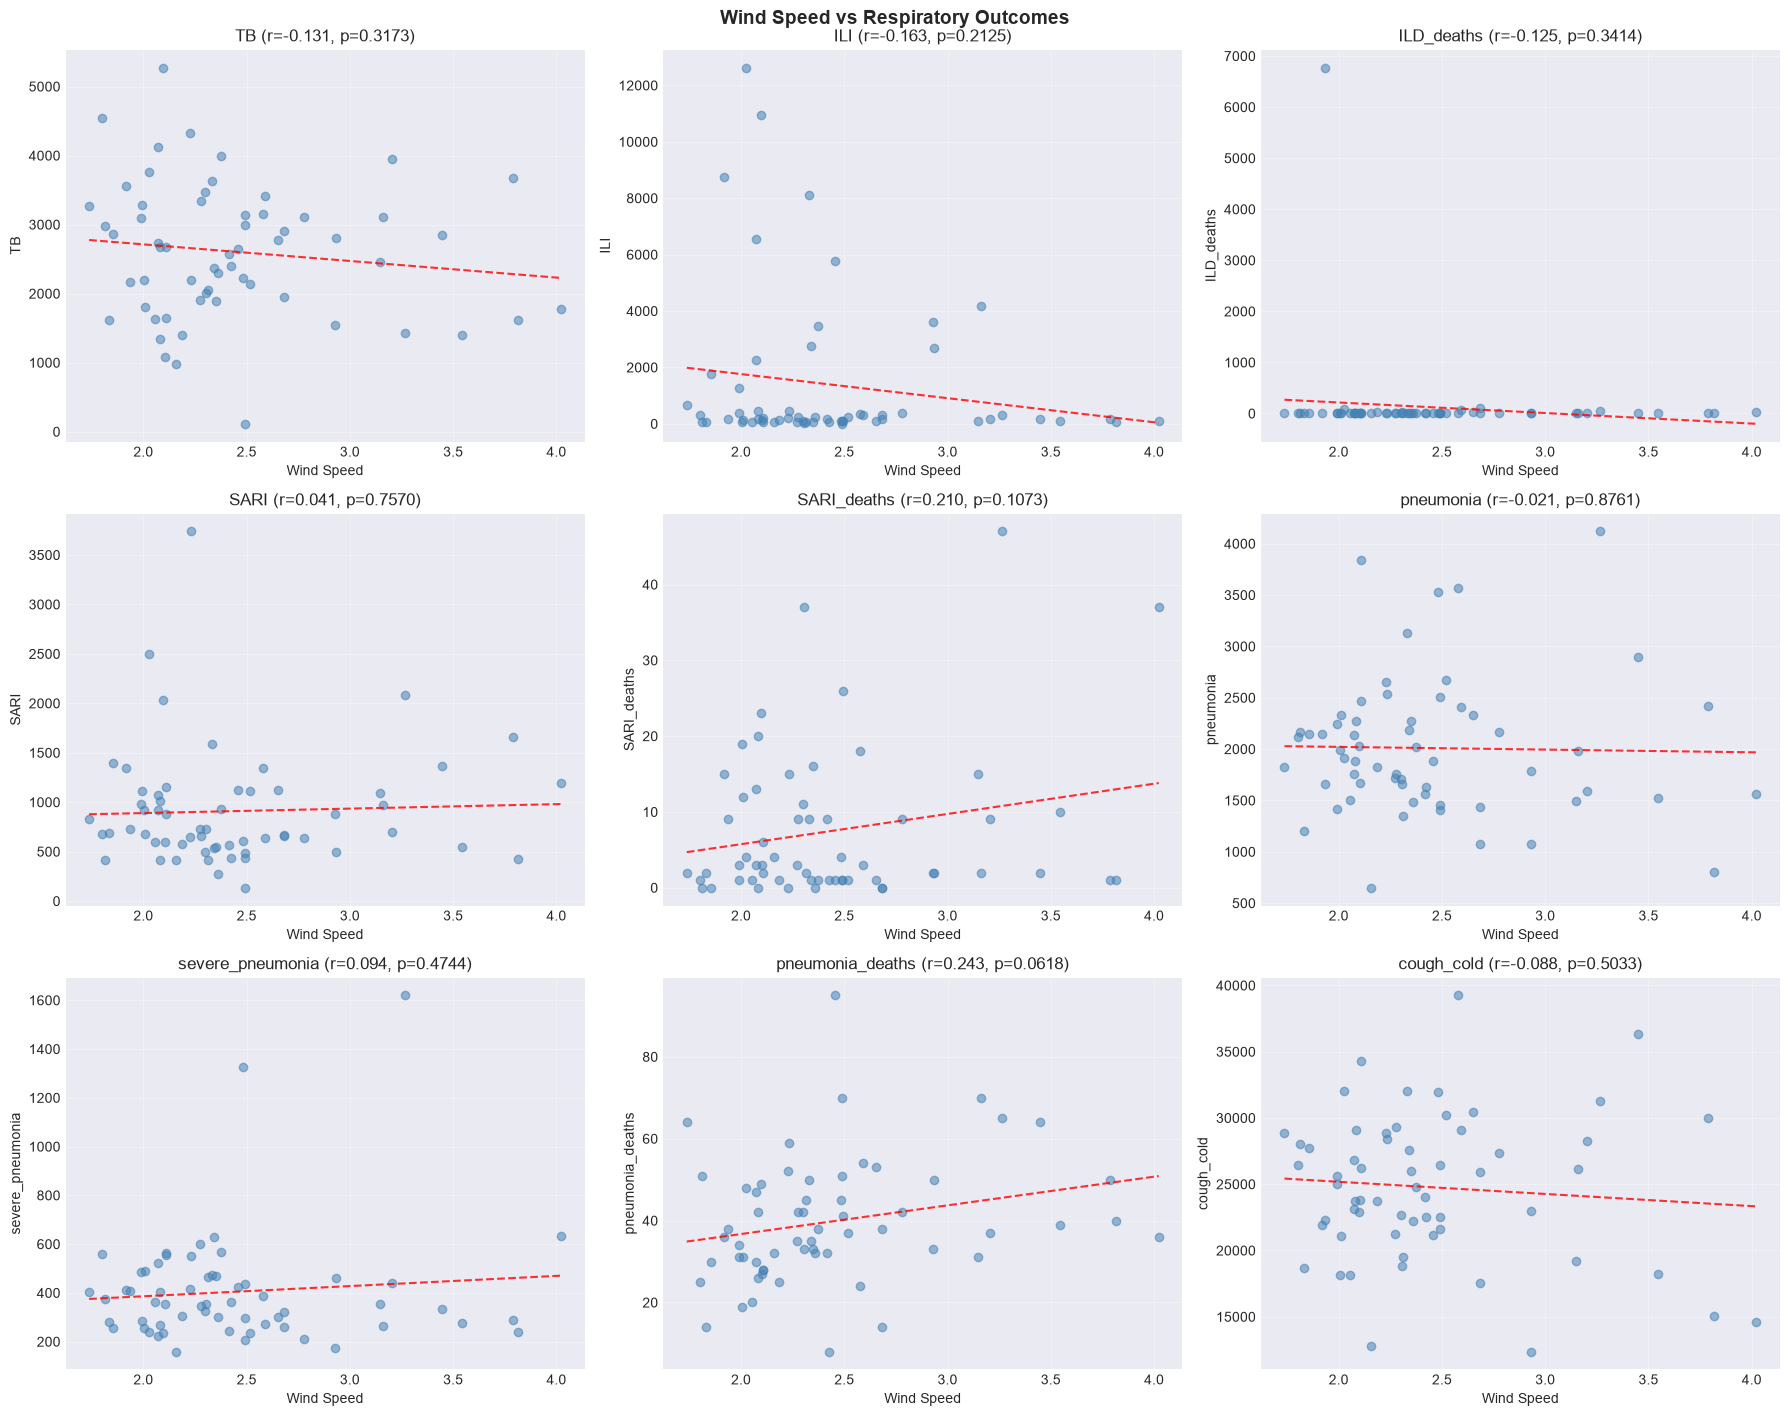

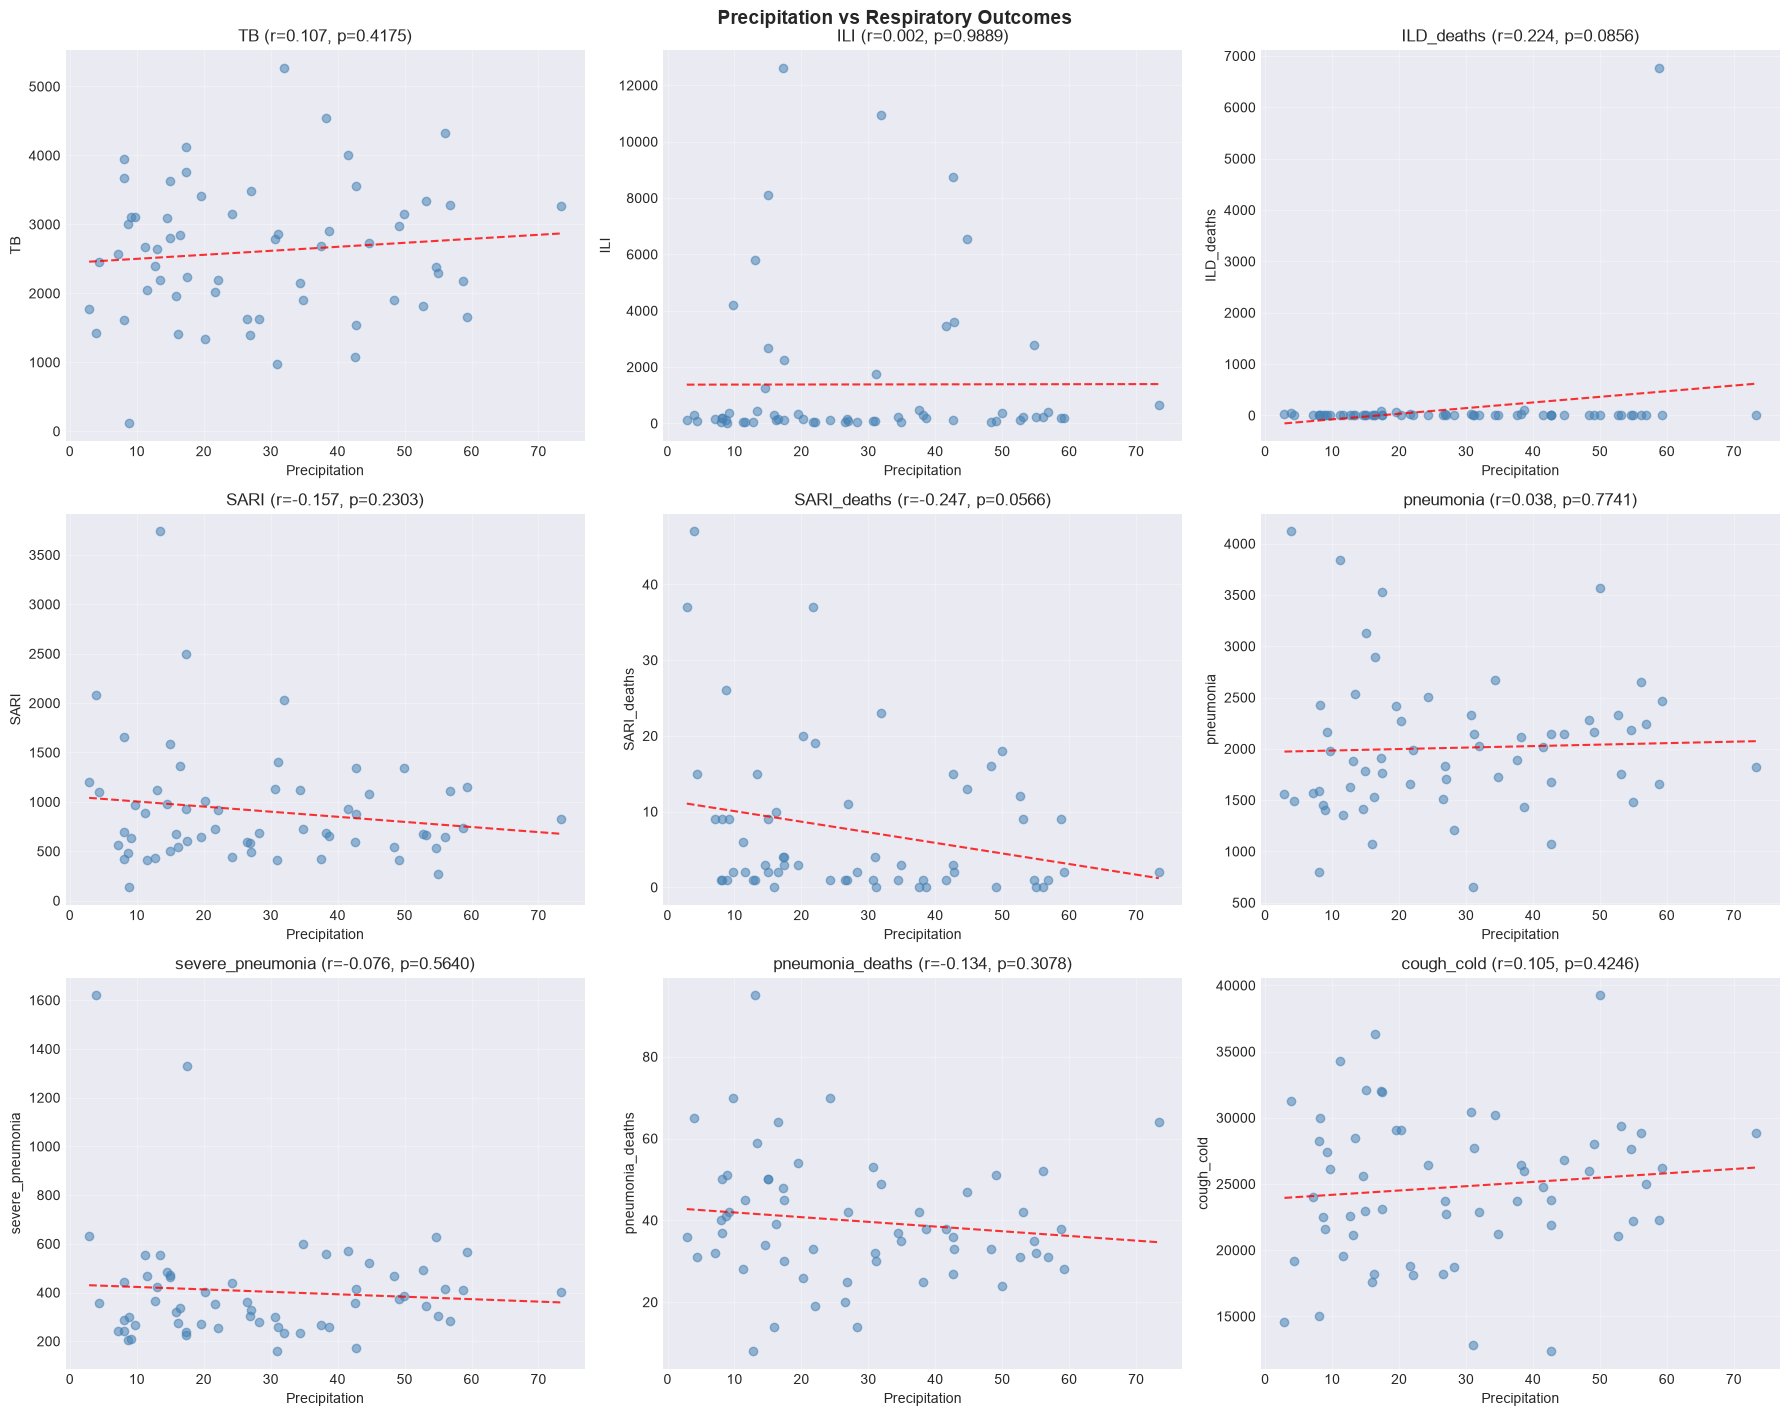

In [13]:
# Core air-quality and climate variables vs disease scatter plots with regression lines
import math
import scipy.stats as stats

disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]
core_feature_labels = {
    'pm2_5': 'PM2.5 (μg/m³)',
    'avgtemp': 'Temperature (°C)',
    'avghumidity': 'Humidity (%)',
    'windspeed': 'Wind Speed',
    'precip': 'Precipitation'
}
core_feature_cols = [col for col in core_feature_labels if col in processed_data.columns]

for feature in core_feature_cols:
    ncols = 3
    nrows = math.ceil(len(disease_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, disease in zip(axes, disease_cols):
        plot_data = processed_data[[feature, disease]].dropna()
        if len(plot_data) < 2:
            ax.text(0.5, 0.5, f'Not enough data for {disease}', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.scatter(plot_data[feature], plot_data[disease], alpha=0.55, color='steelblue')
        slope, intercept = np.polyfit(plot_data[feature], plot_data[disease], 1)
        regression = np.poly1d((slope, intercept))
        x_sorted = np.sort(plot_data[feature].to_numpy())
        ax.plot(x_sorted, regression(x_sorted), 'r--', alpha=0.8)

        corr, p_value = stats.pearsonr(plot_data[feature], plot_data[disease])
        ax.set_title(f'{disease} (r={corr:.3f}, p={p_value:.4f})')
        ax.set_xlabel(core_feature_labels[feature])
        ax.set_ylabel(disease)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(disease_cols):]:
        ax.set_axis_off()

    plt.suptitle(f'{core_feature_labels[feature]} vs Respiratory Outcomes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 2.5 Seasonal Analysis


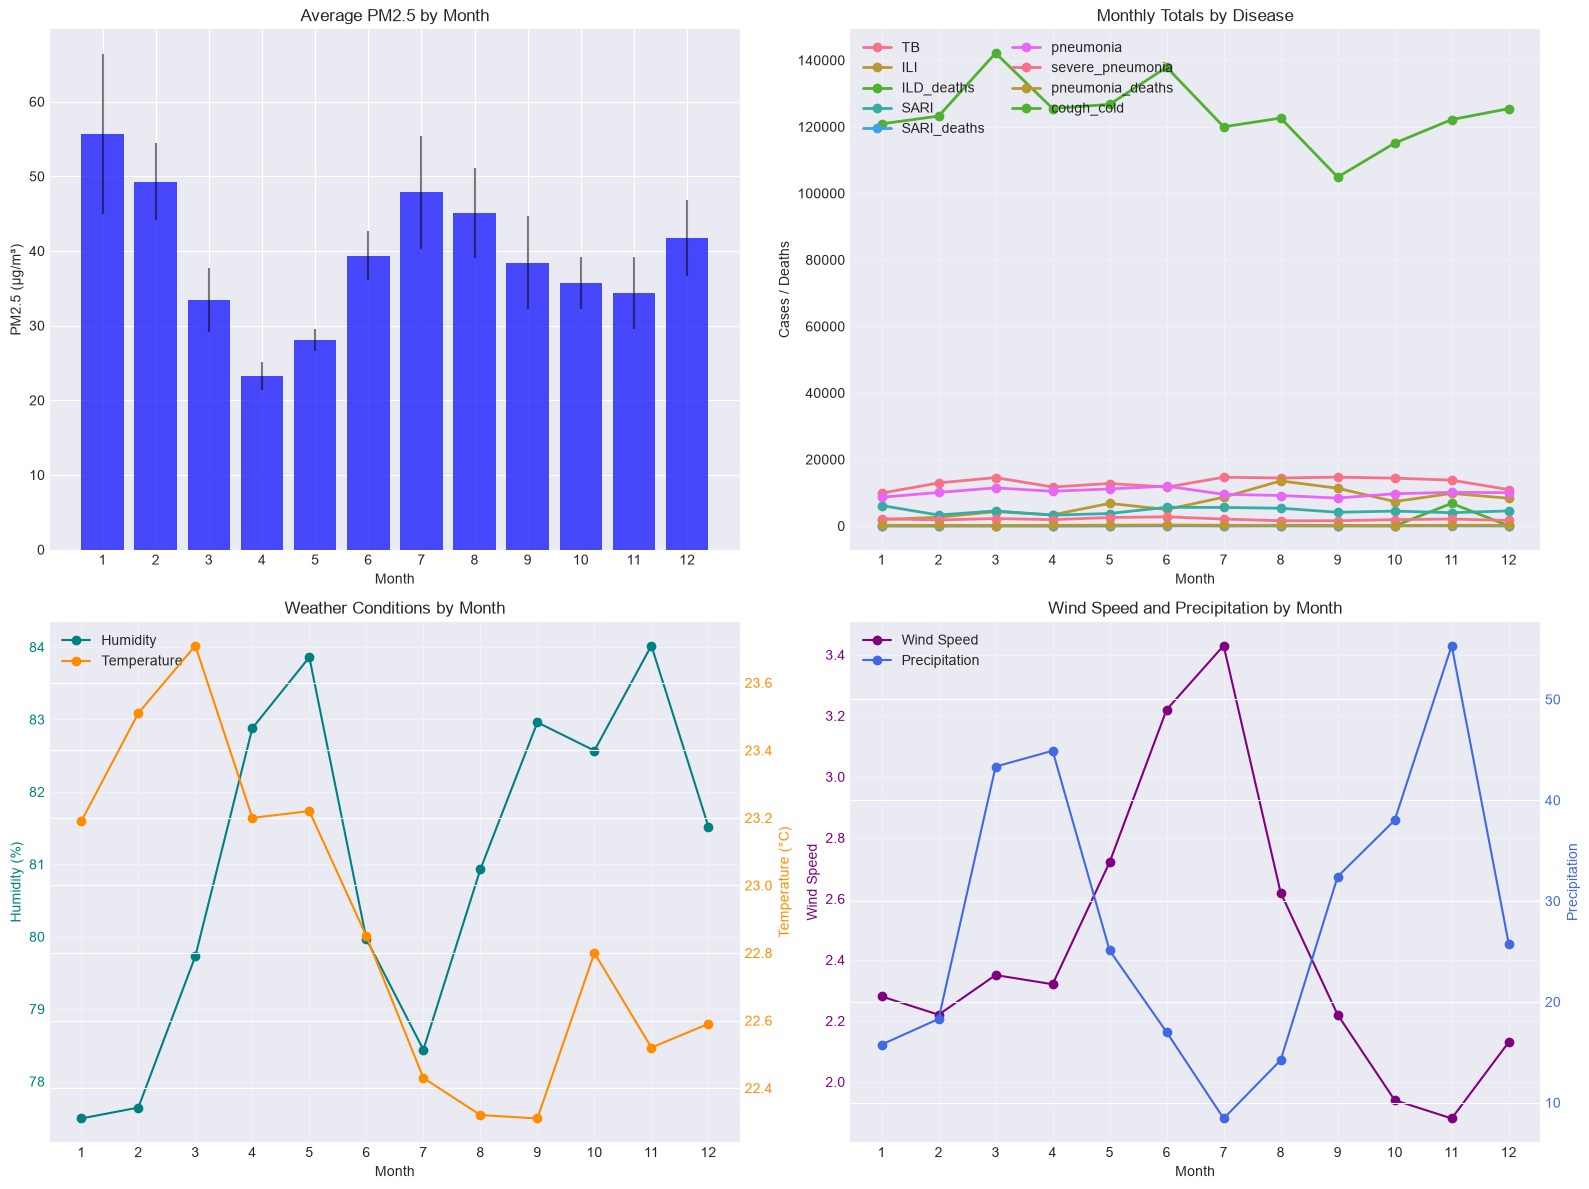

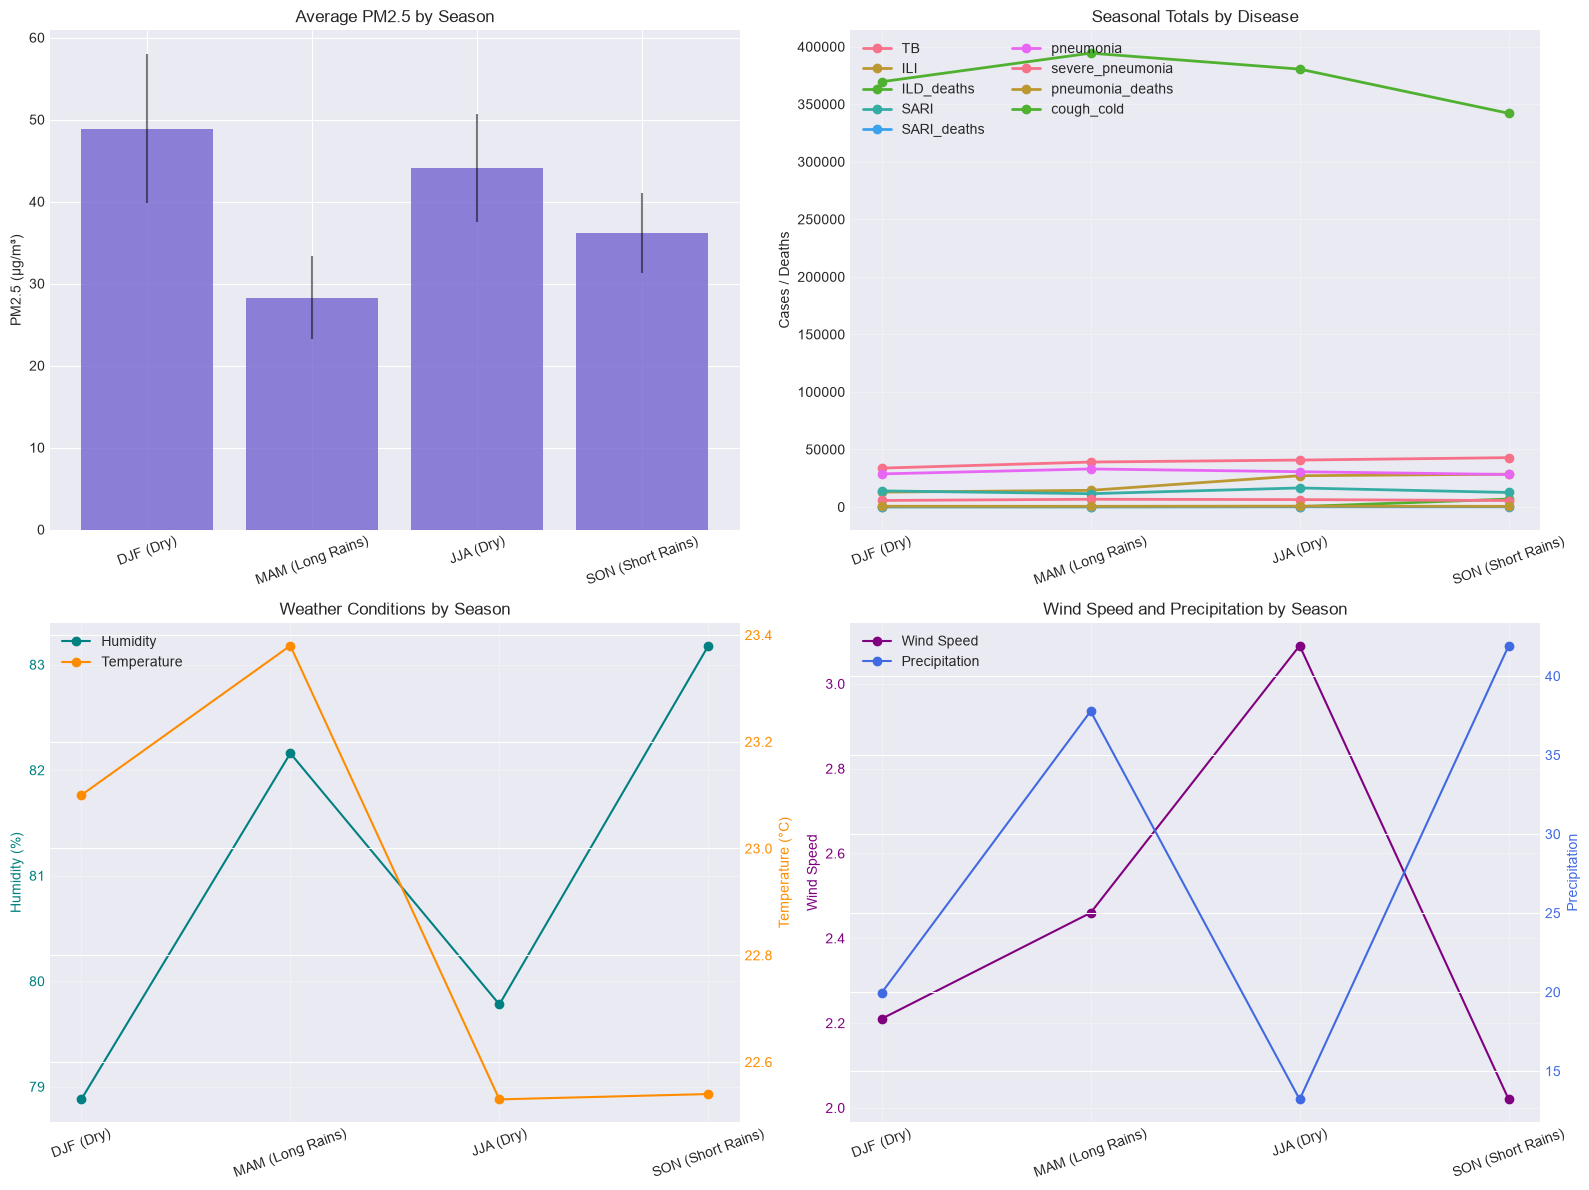

(            TB      ILI  ILD_deaths  SARI  SARI_deaths  pneumonia  \
 month                                                               
 1       9882.0   1914.0        33.0  6143         31.0       8639   
 2      12933.0   2626.0         7.0  3297         40.0      10077   
 3      14544.0   4307.0        34.0  4524         31.0      11444   
 4      11721.0   3346.0        21.0  3250         22.0      10434   
 5      12763.0   6790.0        92.0  3750         12.0      11137   
 6      11683.0   4954.0       155.0  5616         61.0      11959   
 7      14643.0   8647.0        49.0  5563         57.0       9512   
 8      14429.0  13540.0        99.0  5338         29.0       9156   
 9      14685.0  11349.0        30.0  4119         72.0       8391   
 10     14372.0   7344.0        33.0  4474         36.0       9697   
 11     13788.0   9788.0      6801.0  3990         38.0      10119   
 12     10930.0   8343.0        45.0  4527         22.0      10006   
 
        severe_pne

In [14]:
# Monthly and seasonal patterns across all diseases and key features
processed_data['month'] = processed_data['date'].dt.month
processed_data['season'] = processed_data['month'].map({
    12: 'DJF (Dry)', 1: 'DJF (Dry)', 2: 'DJF (Dry)',
    3: 'MAM (Long Rains)', 4: 'MAM (Long Rains)', 5: 'MAM (Long Rains)',
    6: 'JJA (Dry)', 7: 'JJA (Dry)', 8: 'JJA (Dry)',
    9: 'SON (Short Rains)', 10: 'SON (Short Rains)', 11: 'SON (Short Rains)'
})

disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
    if col in processed_data.columns
]
monthly_feature_cols = [
    col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in processed_data.columns
]
monthly_agg = {col: ['mean', 'std'] for col in monthly_feature_cols}
monthly_agg.update({col: ['mean', 'sum'] for col in disease_cols})
monthly_stats = processed_data.groupby('month').agg(monthly_agg).reindex(range(1, 13)).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(
    range(1, 13),
    monthly_stats['pm2_5']['mean'].values,
    yerr=monthly_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_xticks(range(1, 13))

for disease in disease_cols:
    axes[0, 1].plot(range(1, 13), monthly_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Monthly Totals by Disease')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

monthly_weather_ax = axes[1, 0]
monthly_temperature_ax = monthly_weather_ax.twinx()
monthly_weather_ax.plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
monthly_temperature_ax.plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
monthly_weather_ax.set_title('Weather Conditions by Month')
monthly_weather_ax.set_xlabel('Month')
monthly_weather_ax.set_ylabel('Humidity (%)', color='teal')
monthly_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
monthly_weather_ax.tick_params(axis='y', labelcolor='teal')
monthly_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
monthly_weather_ax.set_xticks(range(1, 13))
monthly_weather_ax.grid(True, alpha=0.3)
monthly_handles, monthly_labels = monthly_weather_ax.get_legend_handles_labels()
monthly_temp_handles, monthly_temp_labels = monthly_temperature_ax.get_legend_handles_labels()
monthly_weather_ax.legend(monthly_handles + monthly_temp_handles, monthly_labels + monthly_temp_labels, loc='upper left')

monthly_wind_ax = axes[1, 1]
monthly_precip_ax = monthly_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    monthly_wind_ax.plot(range(1, 13), monthly_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    monthly_precip_ax.plot(range(1, 13), monthly_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
monthly_wind_ax.set_title('Wind Speed and Precipitation by Month')
monthly_wind_ax.set_xlabel('Month')
monthly_wind_ax.set_ylabel('Wind Speed', color='purple')
monthly_precip_ax.set_ylabel('Precipitation', color='royalblue')
monthly_wind_ax.tick_params(axis='y', labelcolor='purple')
monthly_precip_ax.tick_params(axis='y', labelcolor='royalblue')
monthly_wind_ax.set_xticks(range(1, 13))
monthly_wind_ax.grid(True, alpha=0.3)
monthly_wind_handles, monthly_wind_labels = monthly_wind_ax.get_legend_handles_labels()
monthly_precip_handles, monthly_precip_labels = monthly_precip_ax.get_legend_handles_labels()
monthly_wind_ax.legend(monthly_wind_handles + monthly_precip_handles, monthly_wind_labels + monthly_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

season_order = ['DJF (Dry)', 'MAM (Long Rains)', 'JJA (Dry)', 'SON (Short Rains)']
seasonal_stats = processed_data.groupby('season').agg(monthly_agg).reindex(season_order).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(season_order, seasonal_stats['pm2_5']['mean'].values, color='slateblue', alpha=0.75)
axes[0, 0].errorbar(
    season_order,
    seasonal_stats['pm2_5']['mean'].values,
    yerr=seasonal_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Season')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].tick_params(axis='x', rotation=20)

for disease in disease_cols:
    axes[0, 1].plot(season_order, seasonal_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Seasonal Totals by Disease')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

seasonal_weather_ax = axes[1, 0]
seasonal_temperature_ax = seasonal_weather_ax.twinx()
seasonal_weather_ax.plot(season_order, seasonal_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
seasonal_temperature_ax.plot(season_order, seasonal_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
seasonal_weather_ax.set_title('Weather Conditions by Season')
seasonal_weather_ax.set_ylabel('Humidity (%)', color='teal')
seasonal_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
seasonal_weather_ax.tick_params(axis='y', labelcolor='teal')
seasonal_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
seasonal_weather_ax.tick_params(axis='x', rotation=20)
seasonal_weather_ax.grid(True, alpha=0.3)
seasonal_handles, seasonal_labels = seasonal_weather_ax.get_legend_handles_labels()
seasonal_temp_handles, seasonal_temp_labels = seasonal_temperature_ax.get_legend_handles_labels()
seasonal_weather_ax.legend(seasonal_handles + seasonal_temp_handles, seasonal_labels + seasonal_temp_labels, loc='upper left')

seasonal_wind_ax = axes[1, 1]
seasonal_precip_ax = seasonal_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    seasonal_wind_ax.plot(season_order, seasonal_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    seasonal_precip_ax.plot(season_order, seasonal_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
seasonal_wind_ax.set_title('Wind Speed and Precipitation by Season')
seasonal_wind_ax.set_ylabel('Wind Speed', color='purple')
seasonal_precip_ax.set_ylabel('Precipitation', color='royalblue')
seasonal_wind_ax.tick_params(axis='y', labelcolor='purple')
seasonal_precip_ax.tick_params(axis='y', labelcolor='royalblue')
seasonal_wind_ax.tick_params(axis='x', rotation=20)
seasonal_wind_ax.grid(True, alpha=0.3)
seasonal_wind_handles, seasonal_wind_labels = seasonal_wind_ax.get_legend_handles_labels()
seasonal_precip_handles, seasonal_precip_labels = seasonal_precip_ax.get_legend_handles_labels()
seasonal_wind_ax.legend(seasonal_wind_handles + seasonal_precip_handles, seasonal_wind_labels + seasonal_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

monthly_disease_totals = monthly_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
monthly_disease_totals.columns = [col for col, _ in monthly_disease_totals.columns]
seasonal_disease_totals = seasonal_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
seasonal_disease_totals.columns = [col for col, _ in seasonal_disease_totals.columns]

monthly_disease_totals, seasonal_disease_totals


## Step 3: Spatial Analysis


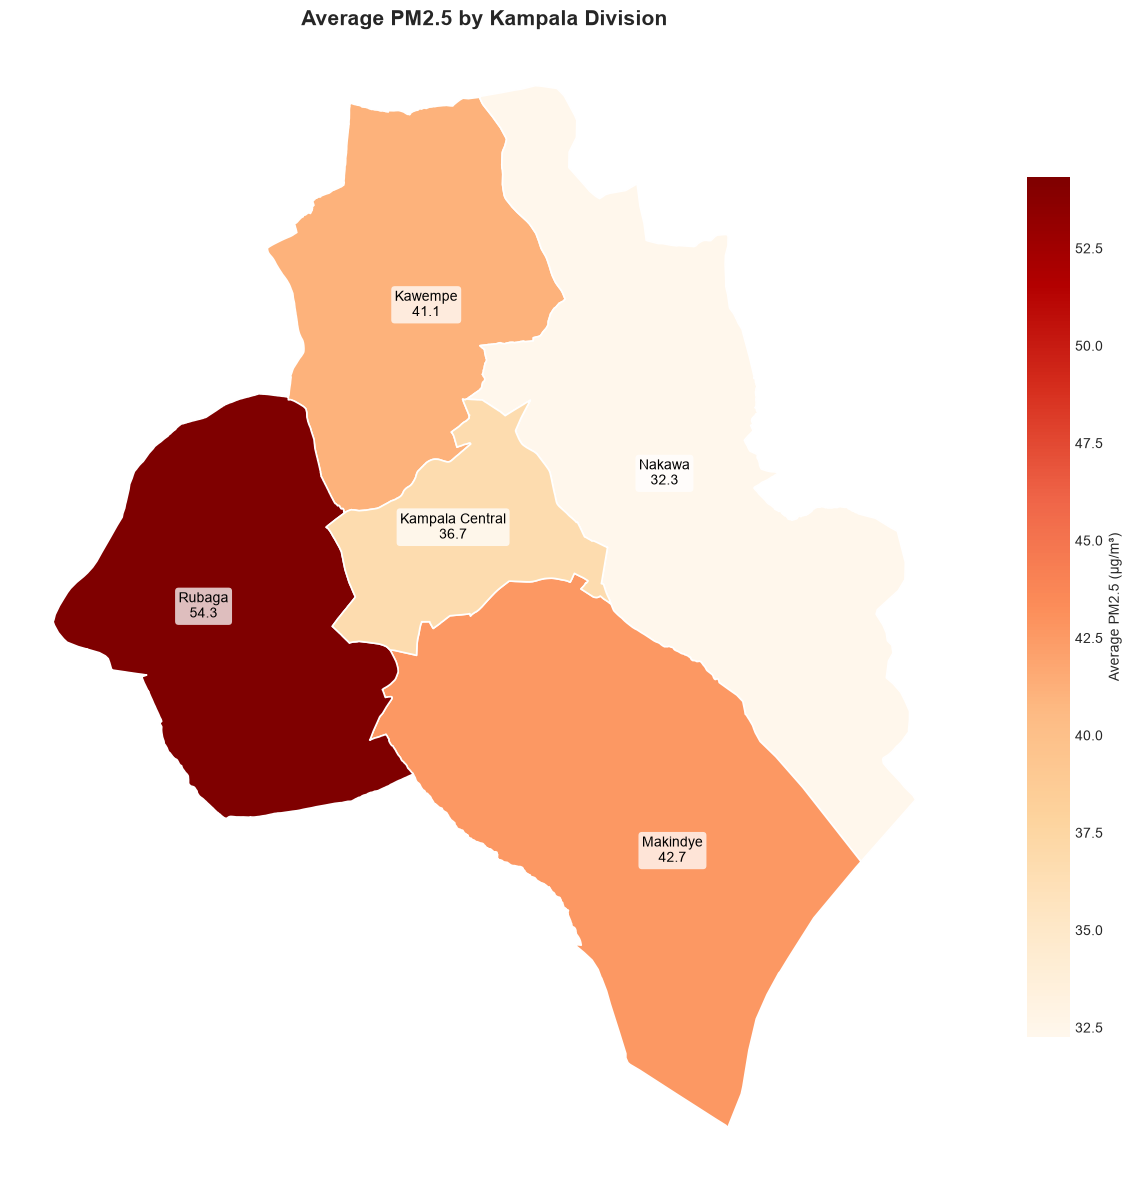

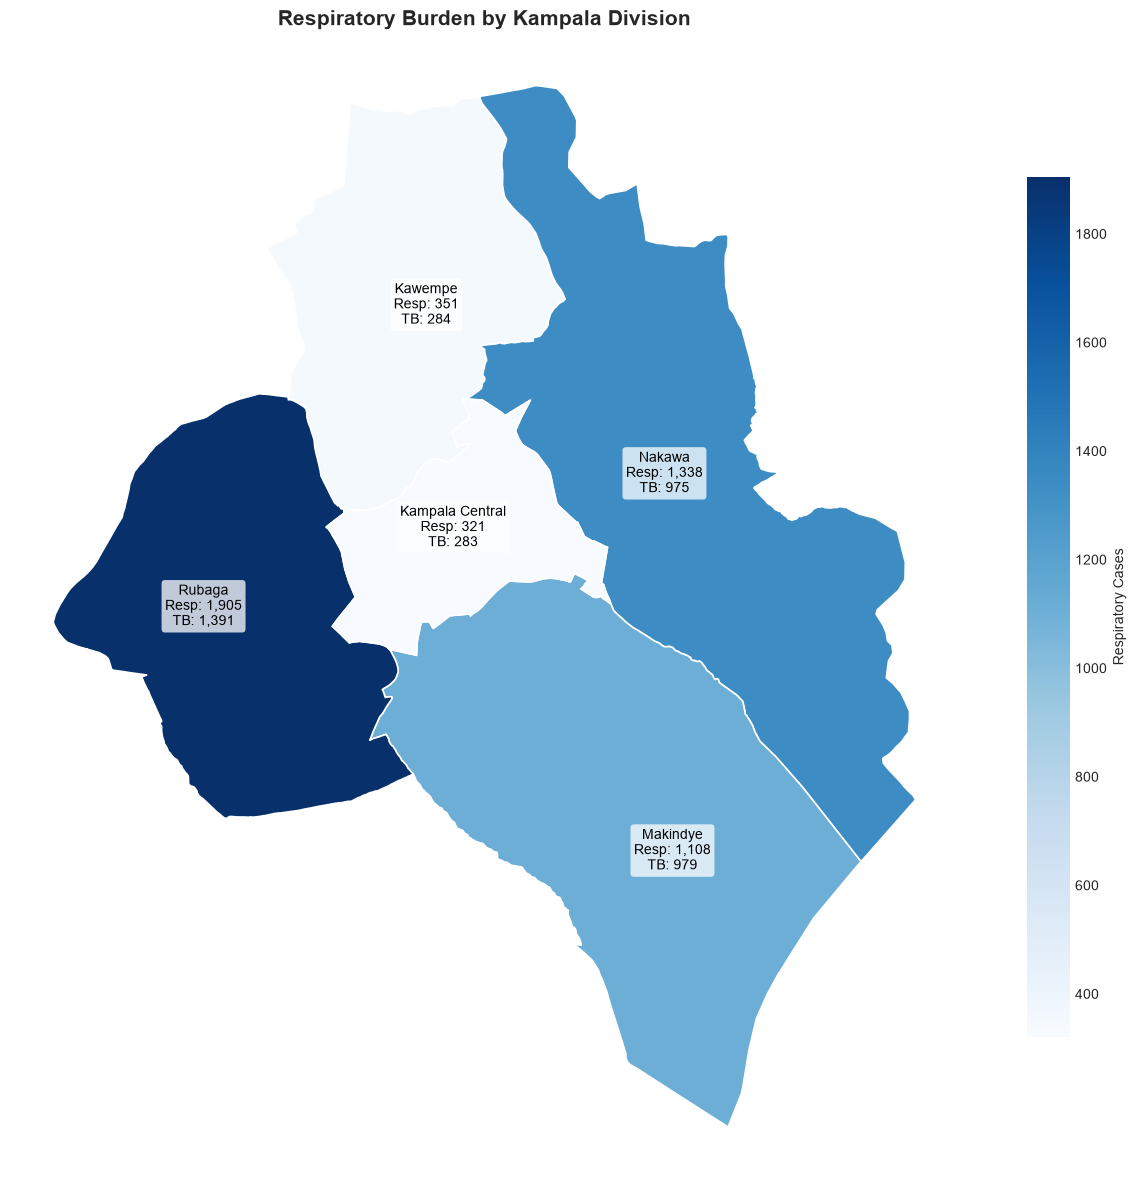

,division,mean_pm25,median_pm25,sensor_sites,monitoring_records,total_respiratory_cases,tb_cases,unique_parishes,dominant_diagnosis,dominant_diagnosis_cases
3,Rubaga,54.334055,47.73570,1,24877,1905,1391,171,Tuberculosis,1391
2,Makindye,42.694804,33.44750,2,53377,1108,979,157,Tuberculosis,979
0,Kawempe,41.058471,31.79715,3,81720,351,284,76,Tuberculosis,284
4,Kampala Central,36.725346,30.46185,1,13214,321,283,71,Tuberculosis,283
1,Nakawa,32.264413,25.41410,2,40520,1338,975,114,Tuberculosis,975


In [15]:
# Kampala-wide spatial analysis using readable division boundary heatmaps
try:
    import geopandas as gpd
except ImportError as exc:
    raise ImportError(
        "Spatial analysis requires geopandas in the active notebook environment."
    ) from exc

from pathlib import Path


def standardize_division(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    mapping = {
        'kampala central': 'Kampala Central',
        'central division': 'Kampala Central',
        'central': 'Kampala Central',
        'kawempe': 'Kawempe',
        'kawempe division': 'Kawempe',
        'nakawa': 'Nakawa',
        'nakawa division': 'Nakawa',
        'makindye': 'Makindye',
        'makindye division': 'Makindye',
        'rubaga': 'Rubaga',
        'rubaga division': 'Rubaga',
        'lubaga': 'Rubaga',
        'lubaga division': 'Rubaga',
    }
    return mapping.get(text, str(value).strip().title())


base_path = Path('data')
shapefile_path = base_path / 'Kampala Shapefile' / 'KMA Subcounties.shp'
air_quality_paths = [
    base_path / 'bq-results-20260322-100500-1774173924222.csv',
    base_path / 'bq-results-20260322-100723-1774174052683.csv',
]
health_path = base_path / 'Exploring_the_Association_Between_Air_Quality_and_the_Burden_of_Respiratory_Tract_Infections_in_Greater_Kampala_Uganda_-_all_versions_-_labels_-_2026-06-23-13-15-43.xlsx'
kampala_order = ['Kampala Central', 'Kawempe', 'Makindye', 'Nakawa', 'Rubaga']

kampala_map = gpd.read_file(shapefile_path)
kampala_map['division'] = kampala_map['sname2019'].apply(standardize_division)
kampala_map = (
    kampala_map[kampala_map['division'].isin(kampala_order)]
    .drop_duplicates(subset=['division'])
    .copy()
)

air_frames = []
for csv_path in air_quality_paths:
    frame = pd.read_csv(
        csv_path,
        usecols=[
            'timestamp', 'site_id', 'site_name', 'pm2_5_calibrated_value', 'parish'
        ]
    )
    air_frames.append(frame)

air_spatial = pd.concat(air_frames, ignore_index=True)
air_spatial = air_spatial.drop_duplicates(subset=['timestamp', 'site_id'])
air_spatial['division'] = air_spatial['site_name'].str.split(',').str[-1].str.strip().apply(standardize_division)
air_spatial.loc[
    air_spatial['parish'].astype(str).str.contains('makindye division', case=False, na=False),
    'division'
] = 'Makindye'
air_spatial = air_spatial[air_spatial['division'].isin(kampala_order)].copy()

division_pm25 = (
    air_spatial.groupby('division', as_index=False)
    .agg(
        mean_pm25=('pm2_5_calibrated_value', 'mean'),
        median_pm25=('pm2_5_calibrated_value', 'median'),
        monitoring_records=('pm2_5_calibrated_value', 'size'),
        sensor_sites=('site_id', 'nunique')
    )
)

health_spatial = pd.read_excel(health_path)
health_spatial['division'] = health_spatial['10. Division (Kampala)'].apply(standardize_division)
health_spatial['diagnosis'] = health_spatial['3. Patient Diagnosis'].fillna('Unknown')
health_spatial = health_spatial[health_spatial['division'].isin(kampala_order)].copy()

division_health = (
    health_spatial.groupby('division', as_index=False)
    .agg(
        total_respiratory_cases=('diagnosis', 'size'),
        tb_cases=('diagnosis', lambda x: (x == 'Tuberculosis').sum()),
        unique_parishes=('12. Parish name:', lambda x: x.dropna().nunique())
    )
)

dominant_diagnosis = (
    health_spatial.groupby(['division', 'diagnosis'])
    .size()
    .reset_index(name='cases')
    .sort_values(['division', 'cases'], ascending=[True, False])
    .drop_duplicates(subset=['division'])
    .rename(columns={'diagnosis': 'dominant_diagnosis', 'cases': 'dominant_diagnosis_cases'})
)

spatial_summary = (
    kampala_map[['division', 'geometry']]
    .merge(division_pm25, on='division', how='left')
    .merge(division_health, on='division', how='left')
    .merge(dominant_diagnosis, on='division', how='left')
)

for col in ['mean_pm25', 'median_pm25', 'monitoring_records', 'sensor_sites', 'total_respiratory_cases', 'tb_cases', 'unique_parishes', 'dominant_diagnosis_cases']:
    spatial_summary[col] = spatial_summary[col].fillna(0)

label_points = spatial_summary.geometry.representative_point()

fig, ax = plt.subplots(figsize=(14, 12))
spatial_summary.plot(
    column='mean_pm25',
    cmap='OrRd',
    linewidth=1.2,
    edgecolor='white',
    legend=True,
    ax=ax,
    legend_kwds={'label': 'Average PM2.5 (μg/m³)', 'shrink': 0.75}
)
for point, division, mean_pm25 in zip(label_points, spatial_summary['division'], spatial_summary['mean_pm25']):
    ax.annotate(
        f"{division}\n{mean_pm25:.1f}",
        (point.x, point.y),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75)
    )
ax.set_title('Average PM2.5 by Kampala Division', fontsize=15, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 12))
spatial_summary.plot(
    column='total_respiratory_cases',
    cmap='Blues',
    linewidth=1.2,
    edgecolor='white',
    legend=True,
    ax=ax,
    legend_kwds={'label': 'Respiratory Cases', 'shrink': 0.75}
)
for point, division, total_cases, tb_cases in zip(
    label_points,
    spatial_summary['division'],
    spatial_summary['total_respiratory_cases'],
    spatial_summary['tb_cases']
):
    ax.annotate(
        f"{division}\nResp: {int(total_cases):,}\nTB: {int(tb_cases):,}",
        (point.x, point.y),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75)
    )
ax.set_title('Respiratory Burden by Kampala Division', fontsize=15, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

spatial_summary_table = spatial_summary[
    [
        'division', 'mean_pm25', 'median_pm25', 'sensor_sites', 'monitoring_records',
        'total_respiratory_cases', 'tb_cases', 'unique_parishes',
        'dominant_diagnosis', 'dominant_diagnosis_cases'
    ]
].sort_values('mean_pm25', ascending=False)
spatial_summary_table


## Step 4: Time Series Modeling


### 4.1 Interrupted Time Series


#### 4.1.1 ITS Preparation and Counterfactual Estimation


In [16]:
# --- 1. Data Preprocessing ---
data_itsa = processed_data.copy()
date_source = processed_data['date'] if 'date' in processed_data.columns else processed_data['ds']
data_itsa['date'] = pd.to_datetime(date_source, errors='coerce', dayfirst=True)
data_itsa = data_itsa.dropna(subset=['date']).sort_values('date').set_index('date')


In [17]:
# --- 2. Handle Missing Data ---
its_numeric_cols = [
    col for col in ['TB', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in data_itsa.columns
]
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].apply(pd.to_numeric, errors='coerce')
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].interpolate(limit_direction='both').ffill().bfill()

print(f"Prepared ITS dataset with {len(data_itsa)} rows and {len(its_numeric_cols)} core numeric features.")


Prepared ITS dataset with 60 rows and 6 core numeric features.


In [18]:
# --- 3. Define the Intervention Point ---
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which corresponds to the date: {intervention_date.date()}")



The dataset has 60 data points.
The intervention is set at index 30, which corresponds to the date: 2022-07-01


In [19]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values


In [20]:
# --- 5. LSTM Modeling for predicted_tb ---

feature_cols = [
    'TB', 'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
    'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2', 'tb_lag_1', 'tb_lag_2',
    'tb_lag_3', 'tb_lag_4', 'pm25_ma_7', 'tb_ma_7', 'pm25_ma_14', 'tb_ma_14',
    'pm25_ma_30', 'tb_ma_30', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'temp_humidity_interaction', 'temp_sat_gap',
    'humidity_sat_gap', 'precip_rolling_4', 'windspeed_rolling_4',
    'pm25_temp_ratio', 'pm25_humidity_ratio', 'tb_pct_change_1', 'tb_diff_1',
    'sin_week', 'cos_week', 'sin_month', 'cos_month', 'time', 'intervention',
    'time_since_intervention'
]

sequence_length = 8
lstm_df = data_itsa[feature_cols].copy().fillna(0)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(lstm_df)
scaled_target = target_scaler.fit_transform(data_itsa[['TB']])

def build_sequences(features, target, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i-seq_len:i])
        y_seq.append(target[i])
    return np.array(X_seq), np.array(y_seq)

X_all, y_all = build_sequences(scaled_features, scaled_target, sequence_length)
train_end = max(sequence_length + 1, intervention_point)
X_train, y_train = X_all[:train_end-sequence_length], y_all[:train_end-sequence_length]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, X_all.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stopping]
)

pred_scaled = lstm_model.predict(X_all, verbose=0)
pred_tb = target_scaler.inverse_transform(pred_scaled).flatten()

data_itsa['predicted_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('predicted_tb')] = pred_tb

counterfactual_features = lstm_df.copy()
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'intervention'] = 0
counterfactual_features.loc[counterfactual_features.index >= intervention_date, 'time_since_intervention'] = 0
scaled_counterfactual = feature_scaler.transform(counterfactual_features.fillna(0))
X_counterfactual, _ = build_sequences(scaled_counterfactual, scaled_target, sequence_length)
counter_scaled = lstm_model.predict(X_counterfactual, verbose=0)
counter_tb = target_scaler.inverse_transform(counter_scaled).flatten()

data_itsa['counterfactual_tb'] = data_itsa['TB'].astype(float)
data_itsa.iloc[sequence_length:, data_itsa.columns.get_loc('counterfactual_tb')] = counter_tb

actual_for_metrics = data_itsa['TB'].iloc[sequence_length:]
pred_for_metrics = data_itsa['predicted_tb'].iloc[sequence_length:]
rmse = np.sqrt(mean_squared_error(actual_for_metrics, pred_for_metrics))
mae = mean_absolute_error(actual_for_metrics, pred_for_metrics)

print("\n--- LSTM Model Summary ---")
print(f"Features used: {len(feature_cols)}")
print(f"Sequence length: {sequence_length} weeks")
print(f"Training windows: {len(X_train)}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")



--- LSTM Model Summary ---
Features used: 48
Sequence length: 8 weeks
Training windows: 22
Best validation loss: 0.004400
RMSE: 719.24
MAE: 540.11


### 4.2 Overall ITS Analysis of TB Cases


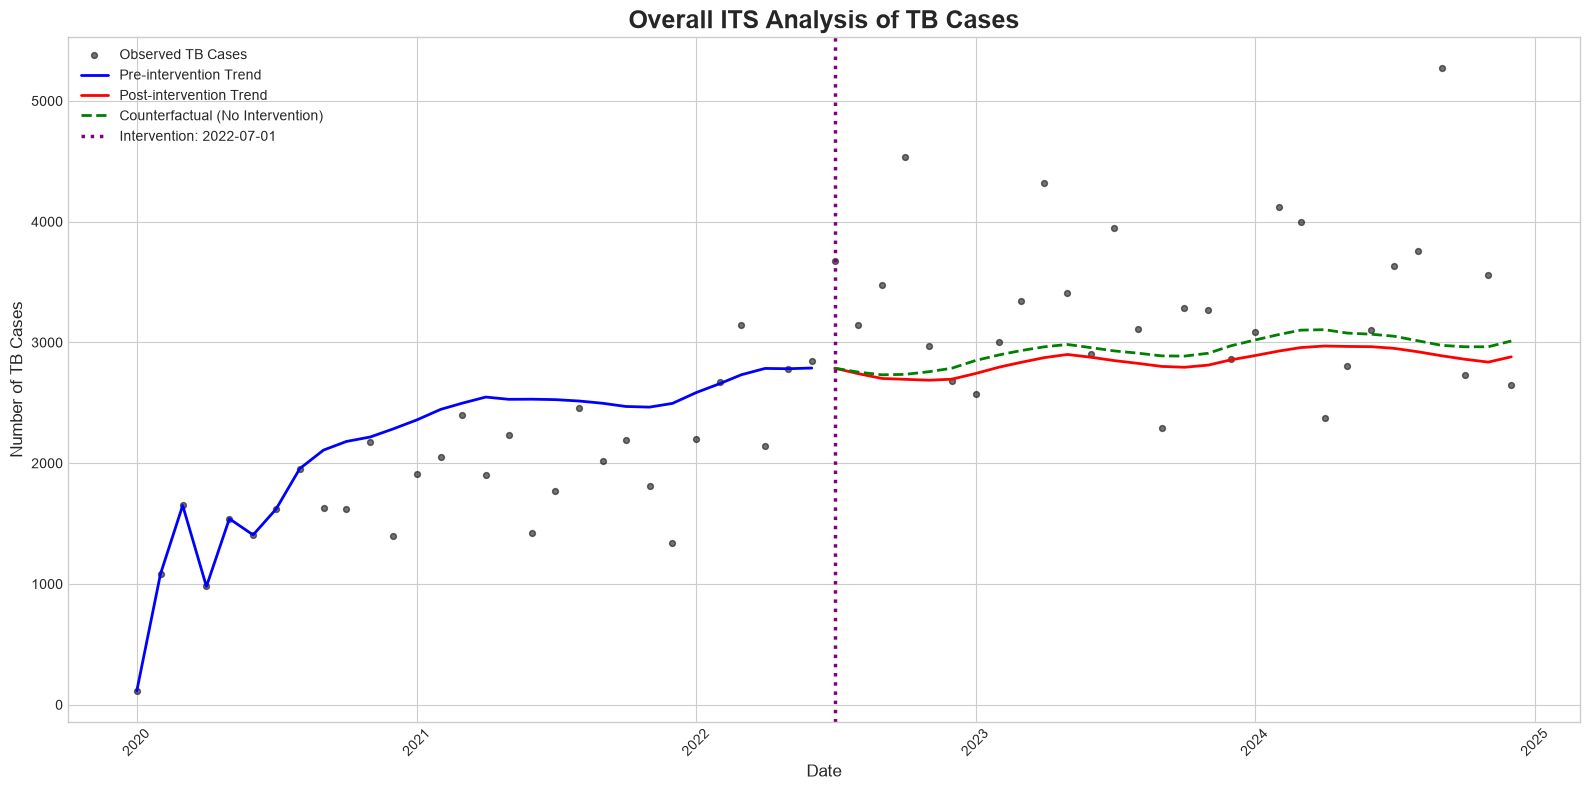

In [21]:
data_itsa.index = pd.to_datetime(data_itsa.index, errors='coerce')

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 8))

ax.scatter(data_itsa.index, data_itsa['TB'], color='black', alpha=0.55, label='Observed TB Cases', s=18)

pre_data = data_itsa[data_itsa['intervention'] == 0]
post_data = data_itsa[data_itsa['intervention'] == 1]
ax.plot(pre_data.index, pre_data['predicted_tb'], color='blue', linewidth=2, label='Pre-intervention Trend')
ax.plot(post_data.index, post_data['predicted_tb'], color='red', linewidth=2, label='Post-intervention Trend')
ax.plot(post_data.index, post_data['counterfactual_tb'], color='green', linestyle='--', linewidth=2, label='Counterfactual (No Intervention)')

ax.axvline(x=intervention_date, color='purple', linestyle=':', linewidth=2.5, label=f'Intervention: {intervention_date.date()}')

ax.set_title('Overall ITS Analysis of TB Cases', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of TB Cases', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4.3 TensorFlow Forecast Preparation


In [22]:
data_project = processed_data.copy()
if 'date' in data_project.columns:
    data_project['ds'] = pd.to_datetime(data_project['date'], errors='coerce', dayfirst=True)
else:
    data_project['ds'] = pd.to_datetime(data_project['ds'], errors='coerce', dayfirst=True)

disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold'] if col in data_project.columns]
data_project = data_project.sort_values('ds').reset_index(drop=True)

if 'county' not in data_project.columns:
    data_project['county'] = 'Kampala'
data_project['year_month'] = data_project['ds'].dt.to_period('M').astype(str)

if 'month' not in data_project.columns:
    data_project['month'] = data_project['ds'].dt.month
if 'week_of_year' not in data_project.columns:
    data_project['week_of_year'] = data_project['ds'].dt.isocalendar().week.astype(int)
if 'quarter' not in data_project.columns:
    data_project['quarter'] = data_project['ds'].dt.quarter
if 'day_of_year' not in data_project.columns:
    data_project['day_of_year'] = data_project['ds'].dt.dayofyear
if 'is_weekend' not in data_project.columns:
    data_project['is_weekend'] = data_project['ds'].dt.dayofweek.isin([5, 6]).astype(int)

if 'time' not in data_project.columns:
    data_project['time'] = np.arange(1, len(data_project) + 1)

if 'intervention' not in data_project.columns or 'time_since_intervention' not in data_project.columns:
    intervention_point = len(data_project) // 2
    intervention_date = data_project.loc[intervention_point, 'ds']
    data_project['intervention'] = (data_project['ds'] >= intervention_date).astype(int)
    data_project['time_since_intervention'] = np.where(
        data_project['intervention'] == 1,
        np.arange(len(data_project)) - intervention_point,
        0
    )
else:
    intervention_date = data_project.loc[data_project['intervention'].eq(1), 'ds'].min()

print(f"Using {len(disease_cols)} diseases for downstream TensorFlow modeling:")
print(disease_cols)
print(f"Intervention date reference: {pd.to_datetime(intervention_date).date()}")


Using 9 diseases for downstream TensorFlow modeling:
['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'pneumonia_deaths', 'cough_cold']
Intervention date reference: 2022-07-01


### 4.4 TensorFlow Fusion Forecast Helpers


In [23]:
sequence_length = 8

base_sequence_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'avgtemp_sat', 'humidity_sat', 'temp_humidity_interaction',
    'temp_sat_gap', 'humidity_sat_gap', 'precip_rolling_4',
    'windspeed_rolling_4', 'pm25_temp_ratio', 'pm25_humidity_ratio',
    'pm25_trailing_ma_7', 'tb_trailing_ma_7', 'pm25_trailing_ma_14', 'tb_trailing_ma_14',
    'pm25_trailing_ma_30', 'tb_trailing_ma_30', 'pm25_leading_ma_7', 'tb_leading_ma_7',
    'pm25_leading_ma_14', 'tb_leading_ma_14', 'pm25_leading_ma_30', 'tb_leading_ma_30',
    'sin_week', 'cos_week', 'sin_month', 'cos_month'
]
base_dense_candidates = [
    'time', 'intervention', 'time_since_intervention', 'month',
    'week_of_year', 'quarter', 'day_of_year', 'is_weekend',
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month'
]

benchmark_feature_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'temp_humidity_interaction', 'temp_sat_gap', 'humidity_sat_gap',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7', 'tb_trailing_ma_7',
    'pm25_trailing_ma_14', 'tb_trailing_ma_14', 'pm25_trailing_ma_30', 'tb_trailing_ma_30',
    'pm25_leading_ma_7', 'tb_leading_ma_7', 'pm25_leading_ma_14', 'tb_leading_ma_14',
    'pm25_leading_ma_30', 'tb_leading_ma_30', 'sin_week', 'cos_week', 'sin_month', 'cos_month'
]


def build_target_features(frame, disease):
    target_frame = frame.copy()
    lag_cols = []
    ma_cols = []
    for lag in [1, 2, 3, 4]:
        col = f'{disease}_lag_{lag}'
        target_frame[col] = target_frame[disease].shift(lag)
        lag_cols.append(col)
    for window in [4, 8]:
        trailing_col = f'{disease}_trailing_ma_{window}'
        target_frame[trailing_col] = target_frame[disease].rolling(window=window, min_periods=1).mean()
        ma_cols.append(trailing_col)
        leading_col = f'{disease}_leading_ma_{window}'
        target_frame[leading_col] = target_frame[disease].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
        ma_cols.append(leading_col)
    diff_col = f'{disease}_diff_1'
    pct_col = f'{disease}_pct_change_1'
    target_frame[diff_col] = target_frame[disease].diff()
    target_frame[pct_col] = target_frame[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    return target_frame, lag_cols, ma_cols, diff_col, pct_col


def create_fusion_arrays(frame, sequence_cols, dense_cols, target_col, seq_len):
    X_seq, X_dense, y, dates = [], [], [], []
    for idx in range(seq_len, len(frame)):
        X_seq.append(frame.loc[idx - seq_len:idx - 1, sequence_cols].to_numpy(dtype=float))
        X_dense.append(frame.loc[idx, dense_cols].to_numpy(dtype=float))
        y.append(float(frame.loc[idx, target_col]))
        dates.append(frame.loc[idx, 'ds'])
    return np.asarray(X_seq), np.asarray(X_dense), np.asarray(y), pd.to_datetime(dates)


def build_fusion_model(seq_shape, dense_dim):
    sequence_input = Input(shape=seq_shape, name='sequence_input')
    sequence_branch = LSTM(32, dropout=0.1, name='sequence_lstm')(sequence_input)
    sequence_branch = Dense(16, activation='relu', name='sequence_dense')(sequence_branch)

    dense_input = Input(shape=(dense_dim,), name='dense_input')
    dense_branch = Dense(16, activation='relu', name='dense_dense')(dense_input)
    dense_branch = Dropout(0.1, name='dense_dropout')(dense_branch)

    fused = Concatenate(name='fusion_concat')([sequence_branch, dense_branch])
    fused = Dense(16, activation='relu', name='fusion_dense')(fused)
    output = Dense(1, name='prediction')(fused)

    model = Model(inputs=[sequence_input, dense_input], outputs=output, name='fusion_lstm_regressor')
    model.compile(optimizer='adam', loss='mse')
    return model


def train_disease_fusion_model(frame, disease, seq_len=8, test_fraction=0.2):
    target_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)

    sequence_cols = [col for col in base_sequence_candidates if col in target_frame.columns]
    sequence_cols += [col for col in lag_cols + ma_cols if col in target_frame.columns]

    dense_cols = [col for col in base_dense_candidates if col in target_frame.columns]
    dense_cols += [col for col in [diff_col, pct_col] if col in target_frame.columns]

    needed_cols = ['ds', disease] + sequence_cols + dense_cols
    model_frame = target_frame[needed_cols].copy().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(model_frame) <= seq_len + 10:
        raise ValueError(f'Not enough usable rows for {disease} after feature engineering.')

    X_seq_raw, X_dense_raw, y_raw, dates = create_fusion_arrays(
        model_frame,
        sequence_cols=sequence_cols,
        dense_cols=dense_cols,
        target_col=disease,
        seq_len=seq_len
    )

    total_samples = len(y_raw)
    split_idx = max(8, int(total_samples * (1 - test_fraction)))
    split_idx = min(split_idx, total_samples - 2)
    if split_idx <= 1:
        raise ValueError(f'Not enough train/test samples for {disease}.')

    X_seq_train_raw = X_seq_raw[:split_idx]
    X_seq_test_raw = X_seq_raw[split_idx:]
    X_dense_train_raw = X_dense_raw[:split_idx]
    X_dense_test_raw = X_dense_raw[split_idx:]
    y_train_raw = y_raw[:split_idx]
    y_test_raw = y_raw[split_idx:]

    sequence_scaler = MinMaxScaler()
    dense_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    sequence_scaler.fit(X_seq_train_raw.reshape(-1, X_seq_train_raw.shape[-1]))
    dense_scaler.fit(X_dense_train_raw)
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    def scale_sequence(values):
        scaled = sequence_scaler.transform(values.reshape(-1, values.shape[-1]))
        return scaled.reshape(values.shape)

    X_seq_train = scale_sequence(X_seq_train_raw)
    X_seq_test = scale_sequence(X_seq_test_raw)
    X_dense_train = dense_scaler.transform(X_dense_train_raw)
    X_dense_test = dense_scaler.transform(X_dense_test_raw)
    y_train = target_scaler.transform(y_train_raw.reshape(-1, 1))

    model = build_fusion_model((seq_len, X_seq_train.shape[-1]), X_dense_train.shape[-1])
    callbacks = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
    history = model.fit(
        [X_seq_train, X_dense_train],
        y_train,
        epochs=40,
        batch_size=min(16, max(4, len(X_seq_train))),
        validation_split=0.2 if len(X_seq_train) >= 12 else 0.0,
        verbose=0,
        callbacks=callbacks if len(X_seq_train) >= 12 else []
    )

    y_train_pred = target_scaler.inverse_transform(
        model.predict([X_seq_train, X_dense_train], verbose=0)
    ).flatten()
    y_test_pred = target_scaler.inverse_transform(
        model.predict([X_seq_test, X_dense_test], verbose=0)
    ).flatten()

    train_residual_std = float(np.std(y_train_raw - y_train_pred)) if len(y_train_raw) > 1 else 0.0
    all_predictions = np.concatenate([y_train_pred, y_test_pred])

    metrics = {
        'Disease': disease,
        'Model': 'TensorFlow Fusion LSTM + Dense',
        'MAE': mean_absolute_error(y_test_raw, y_test_pred),
        'RMSE': mean_squared_error(y_test_raw, y_test_pred) ** 0.5,
        'R²': r2_score(y_test_raw, y_test_pred) if len(y_test_raw) > 1 else np.nan,
        'Train Samples': int(len(y_train_raw)),
        'Test Samples': int(len(y_test_raw))
    }

    prediction_frame = pd.DataFrame({
        'ds': dates,
        'actual': y_raw,
        'predicted': all_predictions,
        'lower': all_predictions - 1.96 * train_residual_std,
        'upper': all_predictions + 1.96 * train_residual_std,
        'dataset_split': ['Train' if idx < split_idx else 'Test' for idx in range(total_samples)]
    })

    return {
        'metrics': metrics,
        'history': history.history,
        'prediction_frame': prediction_frame,
        'sequence_cols': sequence_cols,
        'dense_cols': dense_cols
    }


def run_benchmark_models(frame, disease):
    benchmark_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)
    benchmark_features = [col for col in benchmark_feature_candidates if col in benchmark_frame.columns]
    benchmark_features += [col for col in lag_cols + ma_cols + [diff_col, pct_col] if col in benchmark_frame.columns]

    benchmark_frame = benchmark_frame.copy().replace([np.inf, -np.inf], np.nan)
    benchmark_frame['county'] = benchmark_frame.get('county', 'Kampala')
    benchmark_frame['year_month'] = benchmark_frame['ds'].dt.to_period('M').astype(str)

    ts_modeler = TimeSeriesModeler(benchmark_frame, target_column=disease)
    X_ts, y_ts = ts_modeler.prepare_time_series_data(
        window_size=sequence_length,
        features=benchmark_features,
        target_type='binary'
    )

    if len(X_ts) == 0 or len(y_ts) == 0:
        raise ValueError(f'No usable benchmark windows for {disease}.')

    benchmark_results = ts_modeler.train_models(
        X_ts,
        y_ts,
        models_to_train=['random_forest', 'gradient_boosting', 'svm'],
        cv_splits=3
    )

    if not benchmark_results:
        raise ValueError(f'No benchmark models trained for {disease}.')

    best_model_name = max(benchmark_results, key=lambda name: benchmark_results[name]['avg_f1'])
    best_metrics = benchmark_results[best_model_name]
    return {
        'Disease': disease,
        'Best Benchmark Model': best_model_name,
        'Benchmark Accuracy': best_metrics.get('avg_accuracy', np.nan),
        'Benchmark F1': best_metrics.get('avg_f1', np.nan),
        'Benchmark Precision': best_metrics.get('avg_precision', np.nan),
        'Benchmark Recall': best_metrics.get('avg_recall', np.nan)
    }


### 4.5 TensorFlow Disease Forecasts



=== Training TensorFlow fusion model for TB ===
Train samples: 38, Test samples: 10, MAE: 754.081, RMSE: 860.222, R²: -0.122


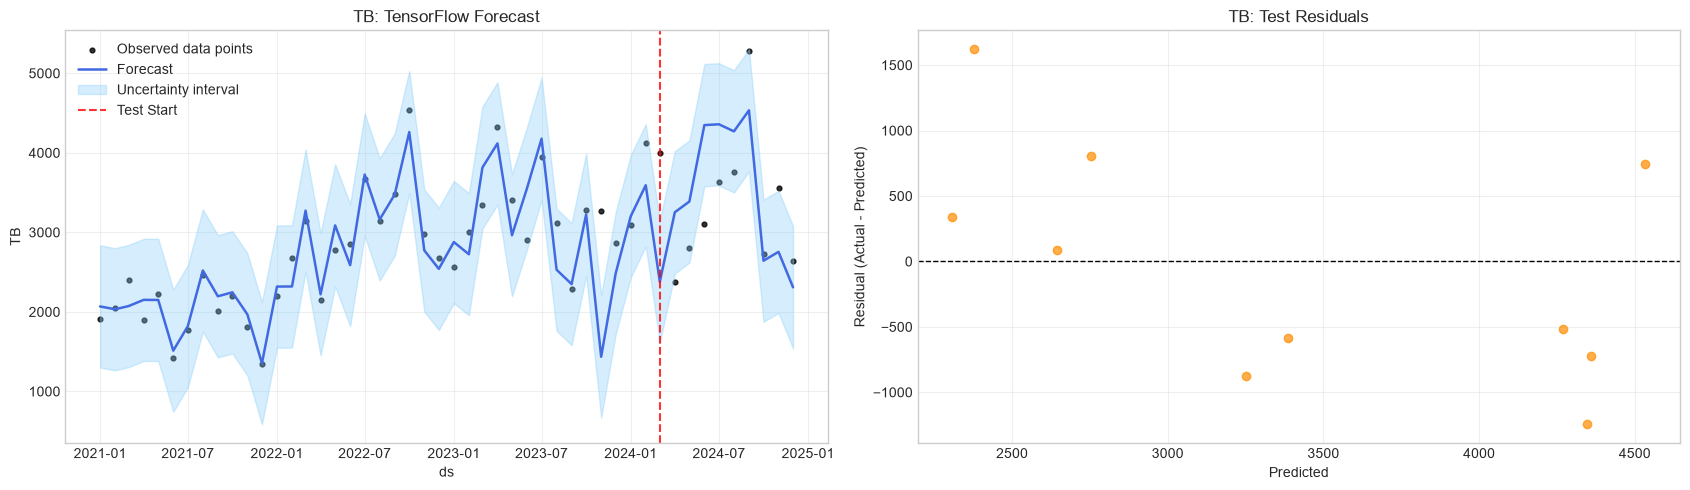

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: TB
INFO:time_series_modeler:Prepared 52 samples with 304 features


=== Benchmarking classical time-series models for TB ===


INFO:time_series_modeler:Training random_forest...


Skipping benchmark models for TB: index 1 is out of bounds for axis 1 with size 1

=== Training TensorFlow fusion model for ILI ===


Train samples: 38, Test samples: 10, MAE: 6549.886, RMSE: 7245.350, R²: -3.842


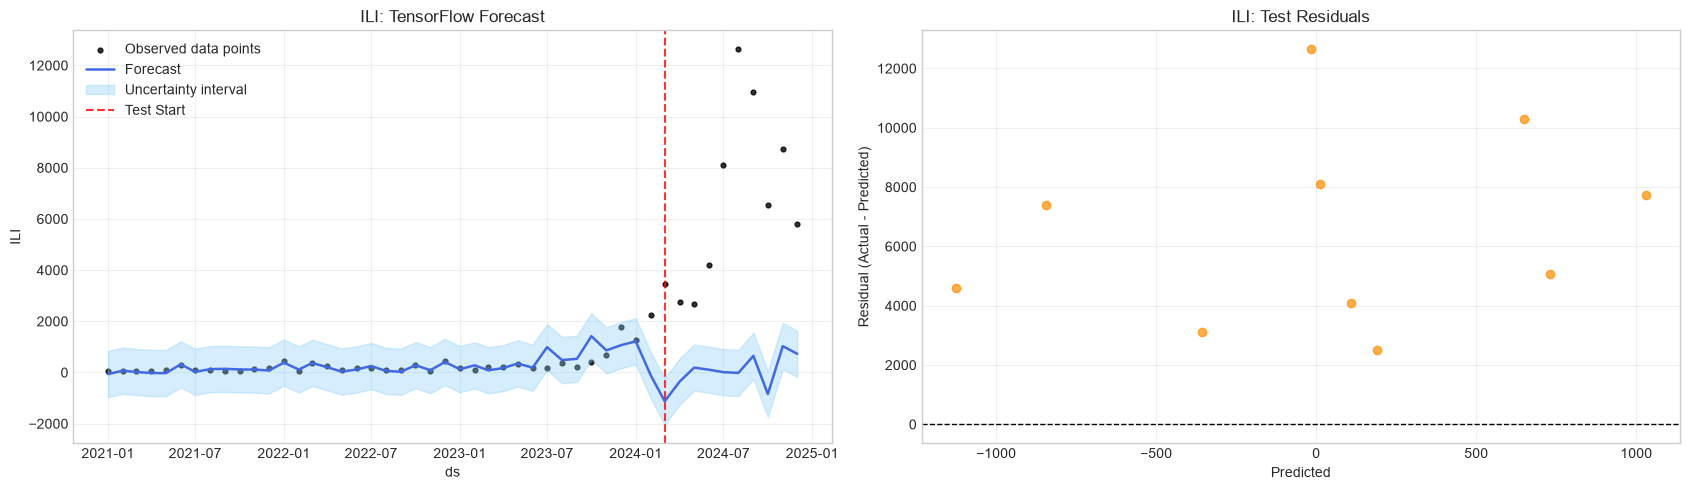

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: ILI
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for ILI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.604)



=== Training TensorFlow fusion model for ILD_deaths ===
Train samples: 20, Test samples: 5, MAE: 48.073, RMSE: 56.312, R²: -1.982


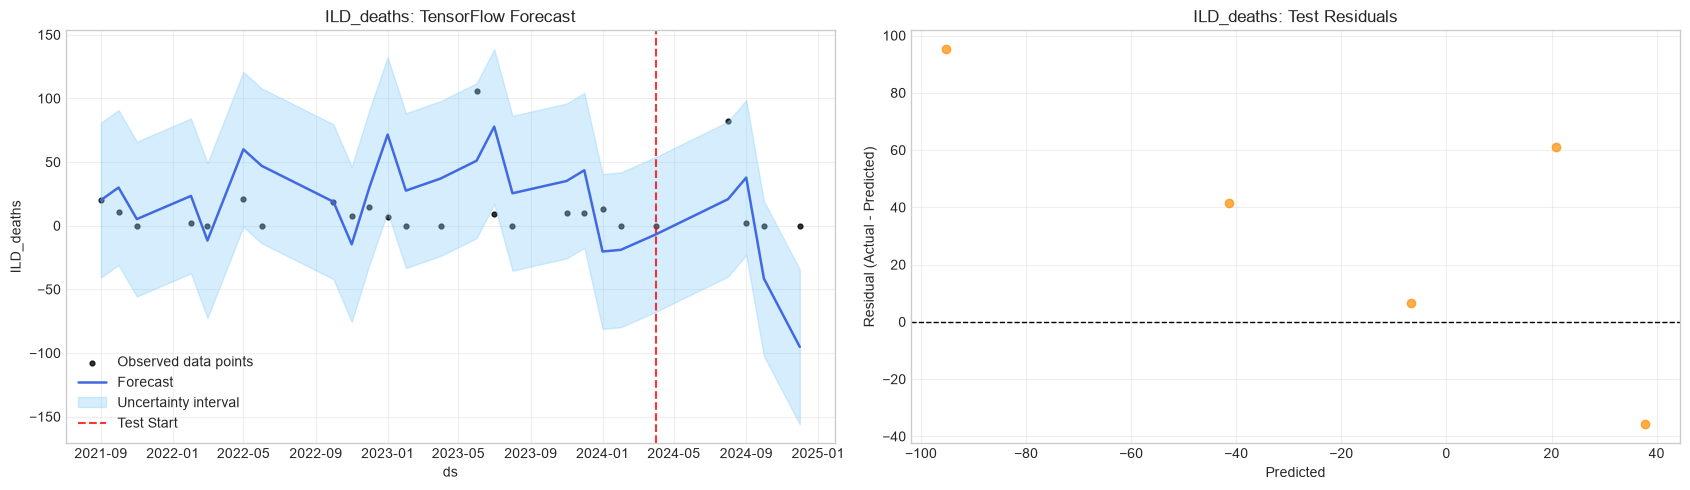

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: ILD_deaths
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for ILD_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.514)



=== Training TensorFlow fusion model for SARI ===
Train samples: 38, Test samples: 10, MAE: 930.988, RMSE: 1123.323, R²: -2.516


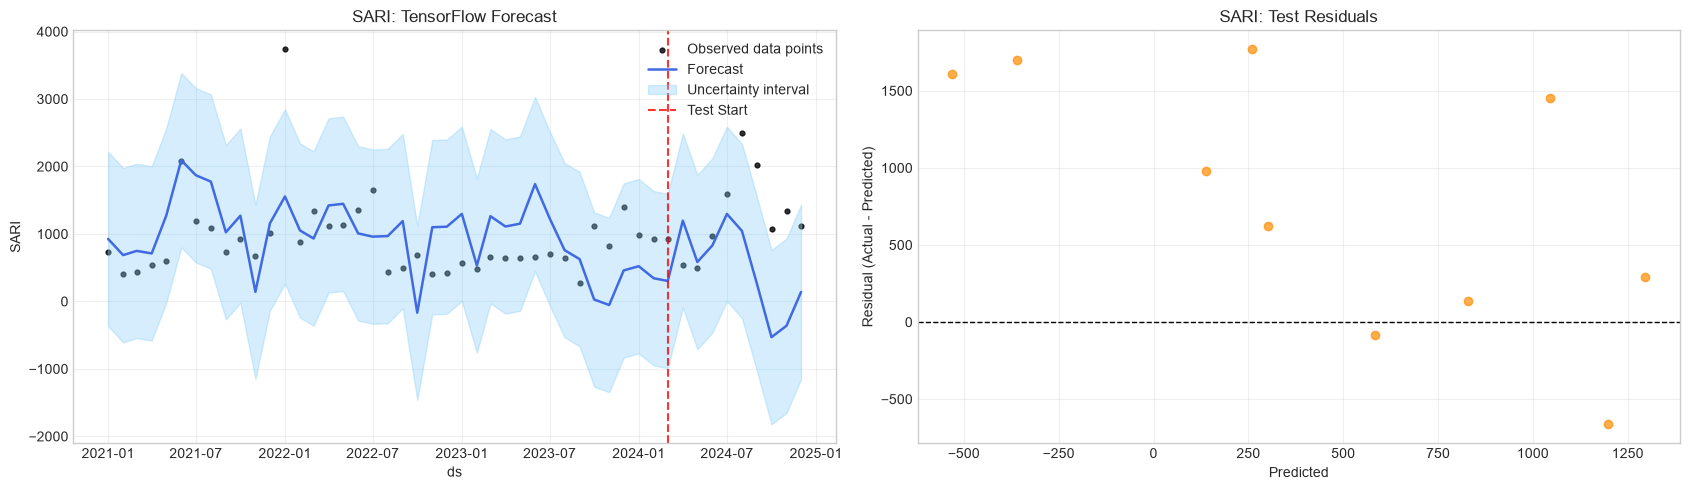

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: SARI
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.652)



=== Training TensorFlow fusion model for SARI_deaths ===
Train samples: 32, Test samples: 9, MAE: 18.624, RMSE: 21.735, R²: -7.757


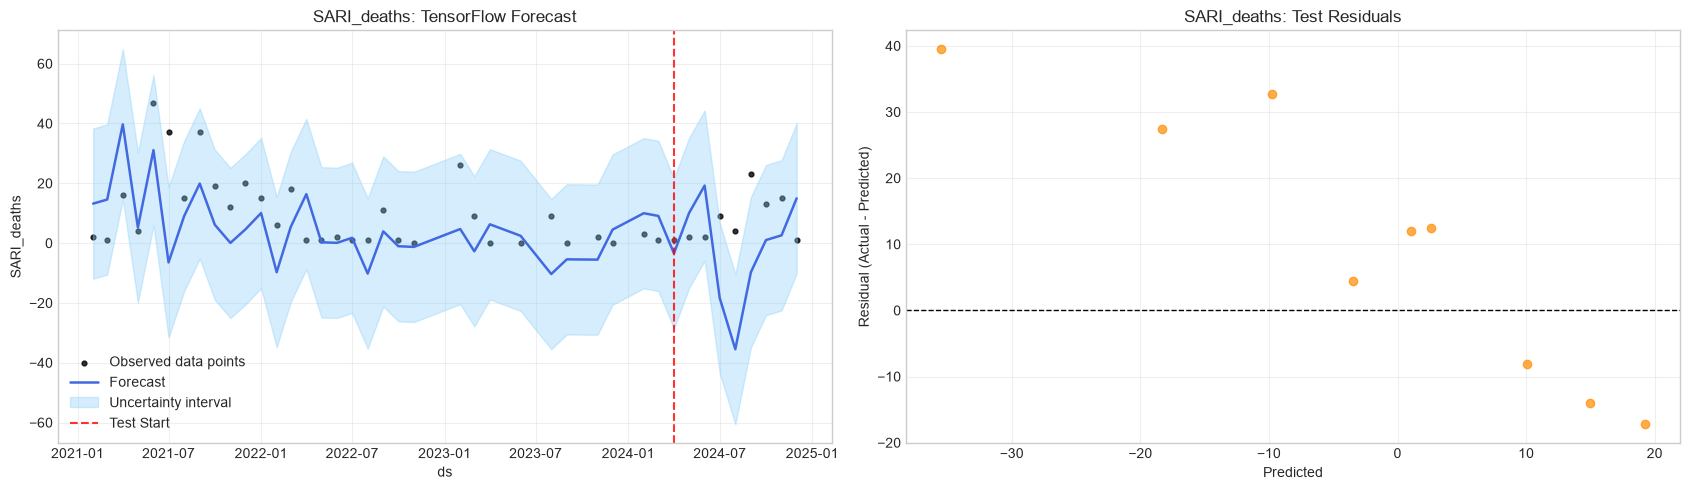

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: SARI_deaths
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.688)



=== Training TensorFlow fusion model for pneumonia ===
Train samples: 38, Test samples: 10, MAE: 1164.716, RMSE: 1353.162, R²: -13.390


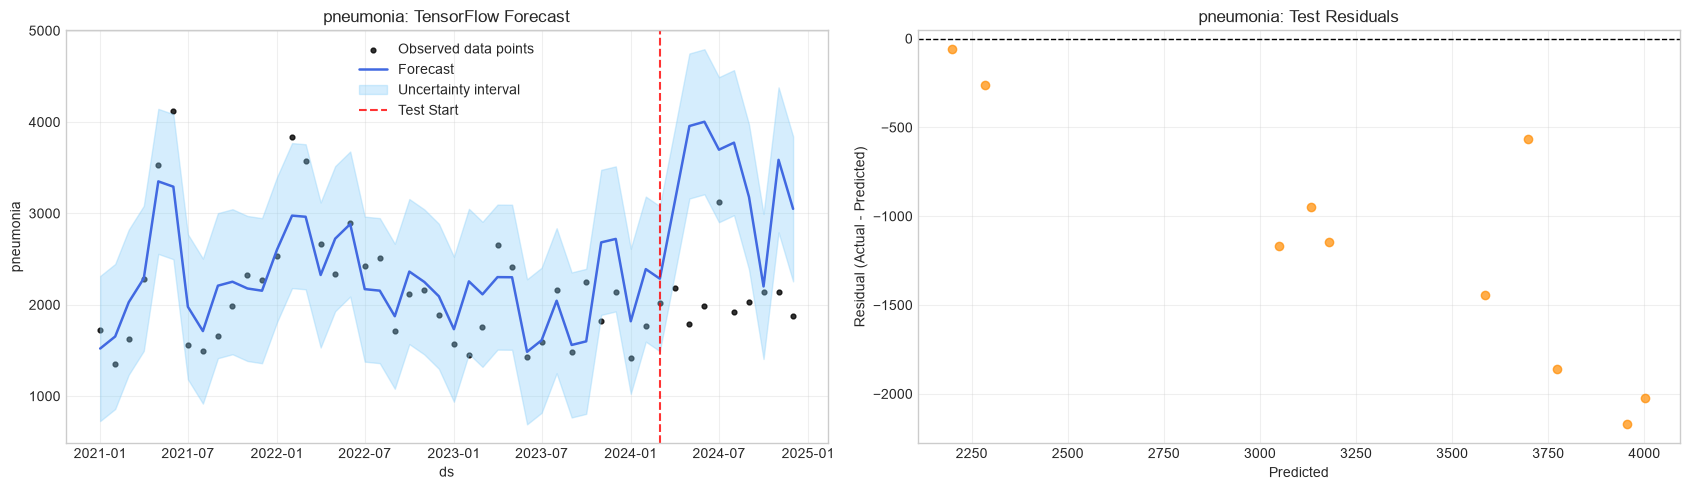

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: pneumonia
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.371)



=== Training TensorFlow fusion model for severe_pneumonia ===
Train samples: 38, Test samples: 10, MAE: 385.542, RMSE: 446.074, R²: -10.523


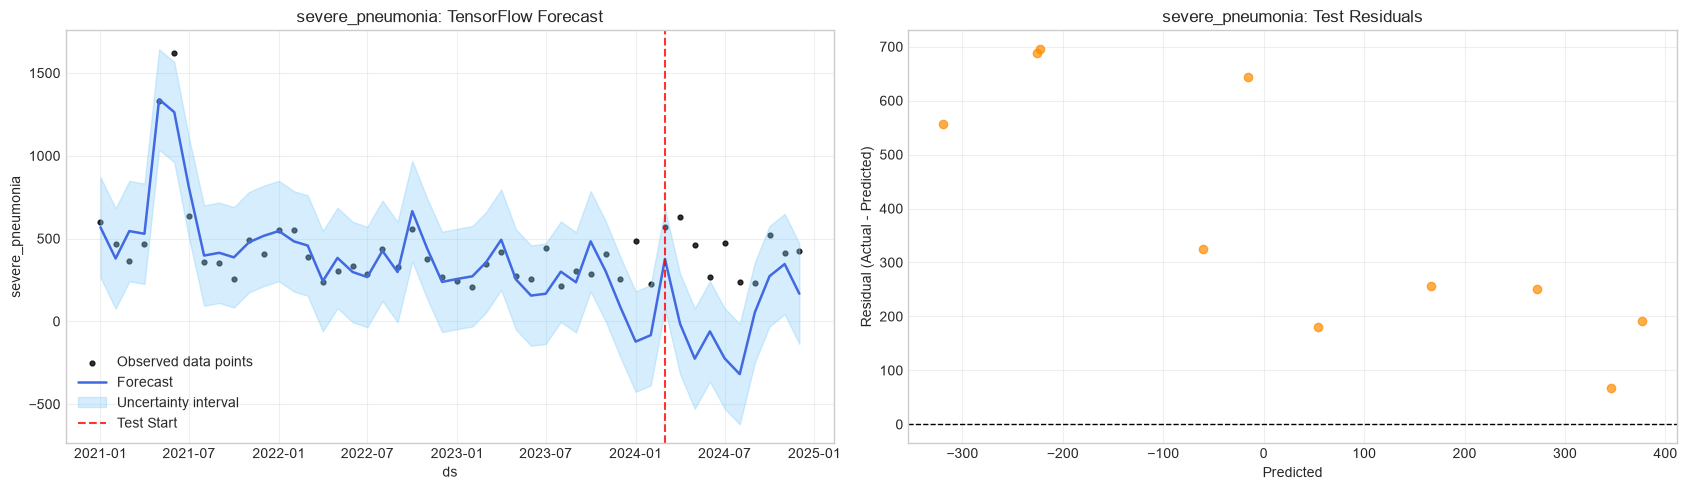

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: severe_pneumonia
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for severe_pneumonia ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.651)



=== Training TensorFlow fusion model for pneumonia_deaths ===
Train samples: 38, Test samples: 10, MAE: 15.582, RMSE: 26.308, R²: -1.329


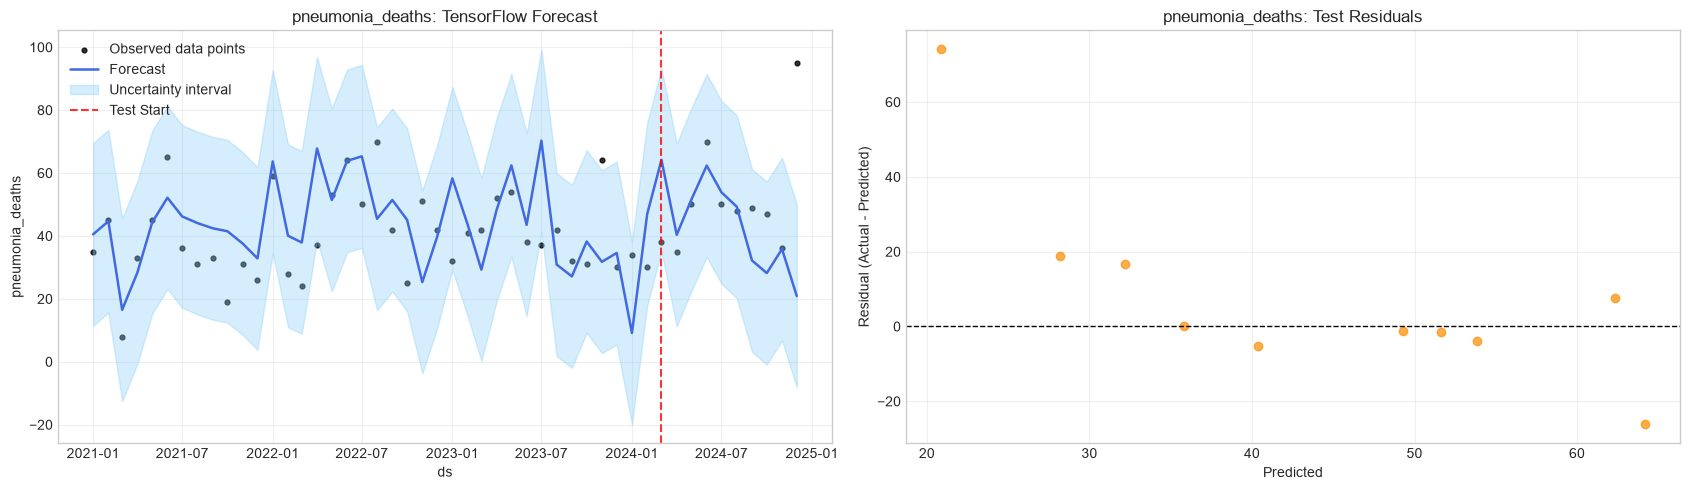

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: pneumonia_deaths
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.546)



=== Training TensorFlow fusion model for cough_cold ===
Train samples: 38, Test samples: 10, MAE: 4112.000, RMSE: 5153.189, R²: -0.945


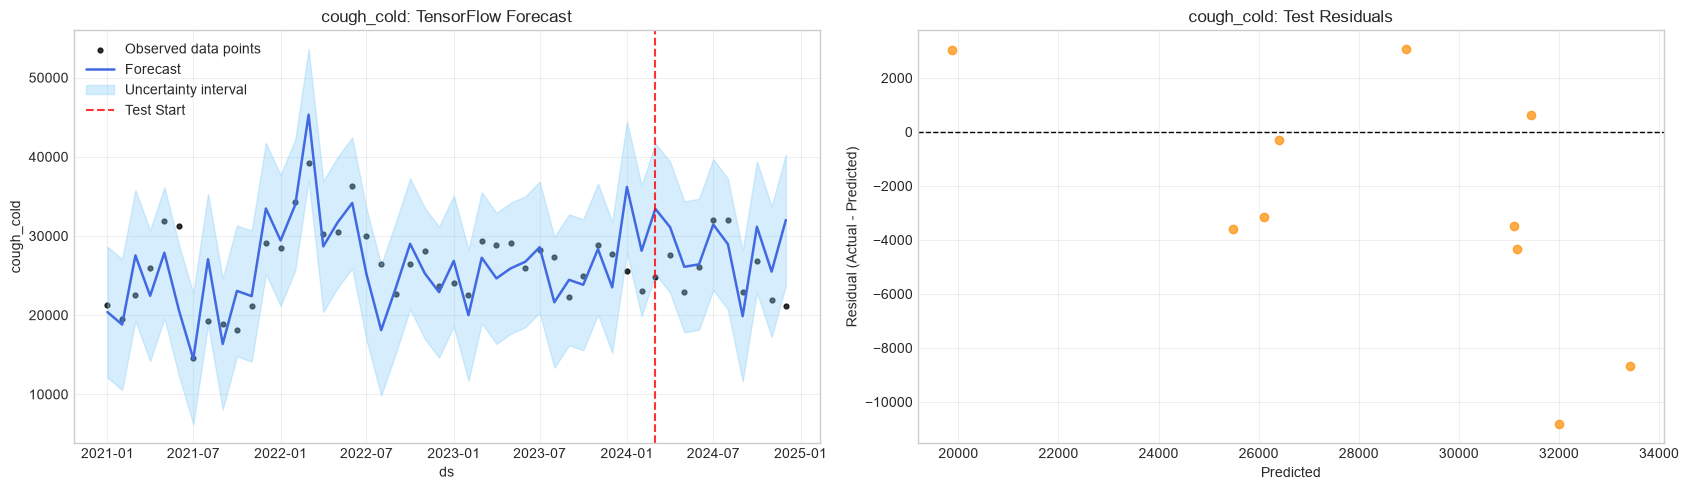

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: cough_cold
INFO:time_series_modeler:Prepared 52 samples with 304 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for cough_cold ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.598)


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,18.624293,21.735464,-7.756719,32,9
1,pneumonia_deaths,TensorFlow Fusion LSTM + Dense,15.581501,26.308153,-1.329112,38,10
2,ILD_deaths,TensorFlow Fusion LSTM + Dense,48.072833,56.311707,-1.982065,20,5
3,severe_pneumonia,TensorFlow Fusion LSTM + Dense,385.541743,446.074307,-10.522941,38,10
4,TB,TensorFlow Fusion LSTM + Dense,754.080640,860.222046,-0.122409,38,10
5,SARI,TensorFlow Fusion LSTM + Dense,930.988278,1123.323165,-2.515638,38,10
6,pneumonia,TensorFlow Fusion LSTM + Dense,1164.716382,1353.161557,-13.389841,38,10
7,cough_cold,TensorFlow Fusion LSTM + Dense,4112.000195,5153.188630,-0.944535,38,10
8,ILI,TensorFlow Fusion LSTM + Dense,6549.885889,7245.349603,-3.842089,38,10


In [24]:
models_performance_records = []
benchmark_records = []
disease_forecasts = {}

for disease in disease_cols:
    print(f"\n=== Training TensorFlow fusion model for {disease} ===")
    try:
        result = train_disease_fusion_model(data_project, disease, seq_len=sequence_length)
        disease_forecasts[disease] = result['prediction_frame']
        models_performance_records.append(result['metrics'])

        plot_df = result['prediction_frame']
        print(
            f"Train samples: {result['metrics']['Train Samples']}, "
            f"Test samples: {result['metrics']['Test Samples']}, "
            f"MAE: {result['metrics']['MAE']:.3f}, "
            f"RMSE: {result['metrics']['RMSE']:.3f}, "
            f"R²: {result['metrics']['R²']:.3f}"
        )

        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        axes[0].scatter(plot_df['ds'], plot_df['actual'], color='black', s=12, alpha=0.8, label='Observed data points')
        axes[0].plot(plot_df['ds'], plot_df['predicted'], color='royalblue', linewidth=1.8, label='Forecast')
        axes[0].fill_between(
            plot_df['ds'],
            plot_df['lower'],
            plot_df['upper'],
            color='lightskyblue',
            alpha=0.35,
            label='Uncertainty interval'
        )
        test_dates = plot_df.loc[plot_df['dataset_split'] == 'Test', 'ds']
        if not test_dates.empty:
            axes[0].axvline(test_dates.iloc[0], color='red', linestyle='--', alpha=0.8, label='Test Start')
        axes[0].set_title(f'{disease}: TensorFlow Forecast')
        axes[0].set_xlabel('ds')
        axes[0].set_ylabel(disease)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        test_df = plot_df[plot_df['dataset_split'] == 'Test'].copy()
        if len(test_df) >= 2:
            residuals = test_df['actual'] - test_df['predicted']
            axes[1].scatter(test_df['predicted'], residuals, alpha=0.7, color='darkorange')
            axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
            axes[1].set_title(f'{disease}: Test Residuals')
            axes[1].set_xlabel('Predicted')
            axes[1].set_ylabel('Residual (Actual - Predicted)')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].axis('off')
            axes[1].text(0.5, 0.5, 'Not enough test points for residual plot', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Skipping TensorFlow model for {disease}: {exc}")

    print(f"=== Benchmarking classical time-series models for {disease} ===")
    try:
        benchmark_records.append(run_benchmark_models(data_project, disease))
    except Exception as exc:
        print(f"Skipping benchmark models for {disease}: {exc}")

models_performance = pd.DataFrame(models_performance_records)
if not models_performance.empty:
    models_performance = models_performance.sort_values('RMSE').reset_index(drop=True)

benchmark_performance = pd.DataFrame(benchmark_records)
if not benchmark_performance.empty:
    benchmark_performance = benchmark_performance.sort_values('Benchmark F1', ascending=False).reset_index(drop=True)

models_performance


### 4.6 Model Comparison


In [25]:
print('--- TensorFlow Fusion Model Summary ---')
if not models_performance.empty:
    print(models_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    best_disease_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"\nBest-performing disease by RMSE: {best_disease_row['Disease']} "
        f"(RMSE={best_disease_row['RMSE']:.3f}, MAE={best_disease_row['MAE']:.3f}, R²={best_disease_row['R²']:.3f})"
    )
else:
    print('No TensorFlow disease models completed successfully.')

print('\n--- Classical Time-Series Benchmark Summary ---')
if not benchmark_performance.empty:
    print(benchmark_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
else:
    print('No benchmark models completed successfully.')

if not models_performance.empty and not benchmark_performance.empty:
    model_comparison = models_performance.merge(benchmark_performance, on='Disease', how='left')
    print('\n--- Per-Disease Model Comparison ---')
    print(
        model_comparison[
            [
                'Disease', 'Model', 'MAE', 'RMSE', 'R²',
                'Best Benchmark Model', 'Benchmark Accuracy', 'Benchmark F1'
            ]
        ].to_string(index=False, float_format=lambda x: f'{x:.3f}')
    )
else:
    model_comparison = pd.DataFrame()

model_comparison


--- TensorFlow Fusion Model Summary ---
         Disease                          Model      MAE     RMSE      R²  Train Samples  Test Samples
     SARI_deaths TensorFlow Fusion LSTM + Dense   18.624   21.735  -7.757             32             9
pneumonia_deaths TensorFlow Fusion LSTM + Dense   15.582   26.308  -1.329             38            10
      ILD_deaths TensorFlow Fusion LSTM + Dense   48.073   56.312  -1.982             20             5
severe_pneumonia TensorFlow Fusion LSTM + Dense  385.542  446.074 -10.523             38            10
              TB TensorFlow Fusion LSTM + Dense  754.081  860.222  -0.122             38            10
            SARI TensorFlow Fusion LSTM + Dense  930.988 1123.323  -2.516             38            10
       pneumonia TensorFlow Fusion LSTM + Dense 1164.716 1353.162 -13.390             38            10
      cough_cold TensorFlow Fusion LSTM + Dense 4112.000 5153.189  -0.945             38            10
             ILI TensorFlow Fusio

,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples,Best Benchmark Model,Benchmark Accuracy,Benchmark F1,Benchmark Precision,Benchmark Recall
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,18.624293,21.735464,-7.756719,32,9,gradient_boosting,0.743590,0.688043,0.664311,0.743590
1,pneumonia_deaths,TensorFlow Fusion LSTM + Dense,15.581501,26.308153,-1.329112,38,10,gradient_boosting,0.589744,0.545596,0.521746,0.589744
2,ILD_deaths,TensorFlow Fusion LSTM + Dense,48.072833,56.311707,-1.982065,20,5,gradient_boosting,0.538462,0.514228,0.632906,0.538462
3,severe_pneumonia,TensorFlow Fusion LSTM + Dense,385.541743,446.074307,-10.522941,38,10,gradient_boosting,0.692308,0.651347,0.706164,0.692308
4,TB,TensorFlow Fusion LSTM + Dense,754.080640,860.222046,-0.122409,38,10,NaN,NaN,NaN,NaN,NaN
5,SARI,TensorFlow Fusion LSTM + Dense,930.988278,1123.323165,-2.515638,38,10,random_forest,0.692308,0.651855,0.619658,0.692308
6,pneumonia,TensorFlow Fusion LSTM + Dense,1164.716382,1353.161557,-13.389841,38,10,random_forest,0.384615,0.371484,0.727506,0.384615
7,cough_cold,TensorFlow Fusion LSTM + Dense,4112.000195,5153.188630,-0.944535,38,10,gradient_boosting,0.641026,0.598135,0.696943,0.641026
8,ILI,TensorFlow Fusion LSTM + Dense,6549.885889,7245.349603,-3.842089,38,10,random_forest,0.666667,0.603582,0.562130,0.666667


## Step 5: Intervention Simulation


In [26]:
# Get baseline metrics
baseline = {
    'baseline_pm25': processed_data['pm2_5'].dropna().mean(),
    'baseline_tb': processed_data['TB'].dropna().mean(),
    'total_tb_cases': processed_data['TB'].dropna().sum()
}

print('Baseline Metrics:')
print(f"- Average PM2.5: {baseline['baseline_pm25']:.2f} μg/m³")
print(f"- Average TB cases: {baseline['baseline_tb']:.2f}")
print(f"- Total TB cases: {baseline['total_tb_cases']:.0f}")


Baseline Metrics:
- Average PM2.5: 39.36 μg/m³
- Average TB cases: 2606.22
- Total TB cases: 156373


In [27]:
# Simulate intervention scenarios
scenarios = {
    'Traffic Control': {'reduction': 0.25, 'cost_factor': 2.5},
    'Green Spaces': {'reduction': 0.15, 'cost_factor': 3.0},
    'Dust Control': {'reduction': 0.20, 'cost_factor': 4.0},
    'Combined': {'reduction': 0.35, 'cost_factor': 5.0}
}

cr_tb = 1.08

results = []
for scenario_name, params in scenarios.items():
    reduced_pm25 = baseline['baseline_pm25'] * (1 - params['reduction'])
    pm25_change = reduced_pm25 - baseline['baseline_pm25']

    relative_risk = cr_tb ** (pm25_change / 10)
    tb_cases_baseline = baseline['total_tb_cases']
    tb_cases_with_intervention = tb_cases_baseline * relative_risk
    tb_cases_prevented = tb_cases_baseline - tb_cases_with_intervention

    cost = params['cost_factor'] * 1000000
    cost_per_case = cost / tb_cases_prevented if tb_cases_prevented > 0 else float('inf')

    results.append({
        'Scenario': scenario_name,
        'PM2.5 Reduction (%)': params['reduction'] * 100,
        'Final PM2.5 (μg/m³)': reduced_pm25,
        'TB Cases Prevented': tb_cases_prevented,
        'Cost Factor': params['cost_factor'],
        'Cost per Case Prevented ($)': cost_per_case
    })

results_df = pd.DataFrame(results)
print('\nIntervention Simulation Results:')
print(results_df.to_string(index=False))



Intervention Simulation Results:
       Scenario  PM2.5 Reduction (%)  Final PM2.5 (μg/m³)  TB Cases Prevented  Cost Factor  Cost per Case Prevented ($)
Traffic Control                 25.0            29.520598        11405.006933          2.5                   219.201971
   Green Spaces                 15.0            33.456678         6946.376457          3.0                   431.879847
   Dust Control                 20.0            31.488638         9192.574244          4.0                   435.133826
       Combined                 35.0            25.584518        15730.599634          5.0                   317.851838


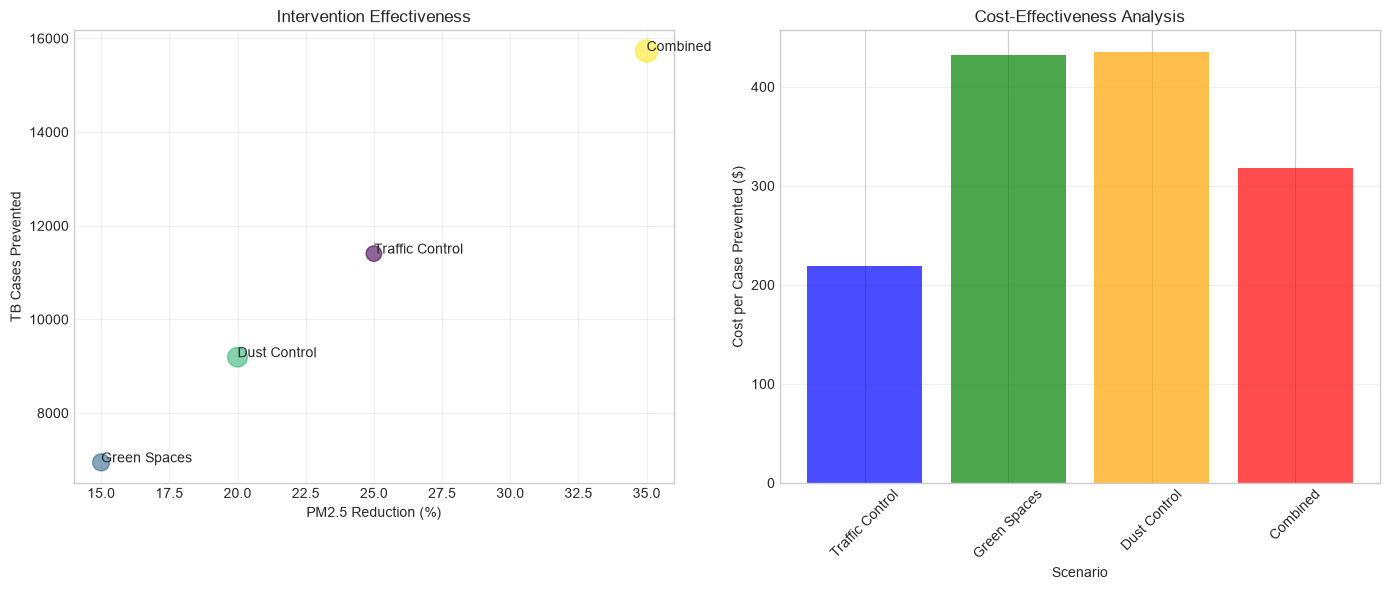

In [28]:
# Visualize intervention impacts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    results_df['PM2.5 Reduction (%)'],
    results_df['TB Cases Prevented'],
    s=results_df['Cost Factor'] * 50,
    alpha=0.6,
    c=range(len(results_df)),
    cmap='viridis'
)
for i, txt in enumerate(results_df['Scenario']):
    axes[0].annotate(
        txt,
        (
            results_df['PM2.5 Reduction (%)'].iloc[i],
            results_df['TB Cases Prevented'].iloc[i]
        )
    )
axes[0].set_xlabel('PM2.5 Reduction (%)')
axes[0].set_ylabel('TB Cases Prevented')
axes[0].set_title('Intervention Effectiveness')
axes[0].grid(True, alpha=0.3)

axes[1].bar(
    results_df['Scenario'],
    results_df['Cost per Case Prevented ($)'],
    color=['blue', 'green', 'orange', 'red'],
    alpha=0.7
)
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Cost per Case Prevented ($)')
axes[1].set_title('Cost-Effectiveness Analysis')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Step 6: Generate Report


In [29]:
# Summary Report
print('=' * 72)
print('KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT')
print('=' * 72)
print()

print('1. DATA OVERVIEW')
print('-' * 40)
print(f"   - Analysis Period: {summary['date_range']}")
print(f"   - Total Records: {summary['total_records']}")
print(f"   - Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"   - Diseases modeled: {', '.join(disease_cols)}")
print()

print('2. TENSORFLOW FUSION MODEL RESULTS')
print('-' * 40)
if models_performance.empty:
    print('   - No disease models completed successfully.')
else:
    for _, row in models_performance.iterrows():
        print(
            f"   - {row['Disease']}: MAE={row['MAE']:.3f}, "
            f"RMSE={row['RMSE']:.3f}, R²={row['R²']:.3f}, "
            f"Train={int(row['Train Samples'])}, Test={int(row['Test Samples'])}"
        )
    best_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"   - Best disease by RMSE: {best_row['Disease']} "
        f"({best_row['RMSE']:.3f})"
    )
print()

print('3. TB INTERVENTION RECOMMENDATIONS')
print('-' * 40)
best_scenario = results_df.loc[results_df['TB Cases Prevented'].idxmax()]
print('   - Intervention simulation remains TB-specific.')
print(f"   - Most Effective: {best_scenario['Scenario']}")
print(f"   - PM2.5 Reduction: {best_scenario['PM2.5 Reduction (%)']:.1f}%")
print(f"   - TB Cases Prevented: {best_scenario['TB Cases Prevented']:.0f}")
print()

print('4. NOTES')
print('-' * 40)
print('   - Seasonal analysis now sits inside exploratory analysis.')
print('   - Spatial analysis combines Kampala divisions, PM2.5 monitors, and hospital records.')
print('   - The overall ITS visualization now sits inside time-series modeling.')
print('   - Each disease now uses its own TensorFlow fusion LSTM + dense regressor.')
print('=' * 72)


KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT

1. DATA OVERVIEW
----------------------------------------
   - Analysis Period: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
   - Total Records: 60
   - Average PM2.5: 39.36 μg/m³
   - Diseases modeled: TB, ILI, ILD_deaths, SARI, SARI_deaths, pneumonia, severe_pneumonia, pneumonia_deaths, cough_cold

2. TENSORFLOW FUSION MODEL RESULTS
----------------------------------------
   - SARI_deaths: MAE=18.624, RMSE=21.735, R²=-7.757, Train=32, Test=9
   - pneumonia_deaths: MAE=15.582, RMSE=26.308, R²=-1.329, Train=38, Test=10
   - ILD_deaths: MAE=48.073, RMSE=56.312, R²=-1.982, Train=20, Test=5
   - severe_pneumonia: MAE=385.542, RMSE=446.074, R²=-10.523, Train=38, Test=10
   - TB: MAE=754.081, RMSE=860.222, R²=-0.122, Train=38, Test=10
   - SARI: MAE=930.988, RMSE=1123.323, R²=-2.516, Train=38, Test=10
   - pneumonia: MAE=1164.716, RMSE=1353.162, R²=-13.390, Train=38, Test=10
   - cough_cold: MAE=4112.000, RMSE=5153.189, R²

In [30]:
# Save downstream results
results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

notebook_tag = 'analysis_month'
results_df.to_csv(results_dir / f'{notebook_tag}_intervention_scenarios.csv', index=False)
models_performance.to_csv(results_dir / f'{notebook_tag}_model_performance.csv', index=False)

print(f"✓ Results saved to results/{notebook_tag}_intervention_scenarios.csv")
print(f"✓ Results saved to results/{notebook_tag}_model_performance.csv")


✓ Results saved to results/analysis_month_intervention_scenarios.csv
✓ Results saved to results/analysis_month_model_performance.csv
